# Objetivo


Você está prevendo se um determinado tweet se refere a um desastre real ou não. Se sim, preveja um valor de 1. Caso contrário, preveja um valor de 0.

# Sumário

- id- um identificador único para cada tweet
- text - o texto do tweet
- location - a localização de onde o tweet foi enviado (pode estar em branco)
- keyword - uma palavra-chave específica do tweet (pode estar em branco)
- target- apenas em train.csv , isso indica se um tweet é sobre um desastre real ( 1) ou não ( 0)

# Importação

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
caminho = '/content/drive/Shareddrives/Rede CC/Rede CC 2.0/1. Áreas/2. Escola de Negócios/4. CCTech/2. Período de Capacitação/11. NLP/João Paulo/train (2).csv'
df_1=pd.read_csv(caminho)

In [ ]:
caminho2 = '/content/drive/Shareddrives/Rede CC/Rede CC 2.0/1. Áreas/2. Escola de Negócios/4. CCTech/2. Período de Capacitação/11. NLP/João Paulo/test (2).csv'
df_2=pd.read_csv(caminho2)

In [ ]:
df = pd.concat([df_1, df_2], ignore_index=True)

In [ ]:
df.shape

(10876, 5)

In [ ]:
df.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1.0
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1.0
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1.0
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1.0
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10876 entries, 0 to 10875
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        10876 non-null  int64  
 1   keyword   10789 non-null  object 
 2   location  7238 non-null   object 
 3   text      10876 non-null  object 
 4   target    7613 non-null   float64
dtypes: float64(1), int64(1), object(3)
memory usage: 425.0+ KB


87 nulos em keyword. Location tem 33% de nulos

In [ ]:
df.describe()

,id,target
count,10876.000000,7613.00000
mean,5437.500000,0.42966
std,3139.775098,0.49506
min,0.000000,0.00000
25%,2718.750000,0.00000
50%,5437.500000,0.00000
75%,8156.250000,1.00000
max,10875.000000,1.00000


In [ ]:
df.isnull().sum()

,0
id,0
keyword,87
location,3638
text,0
target,3263


avaliando o balanceamento da variável target


In [ ]:
print(df['target'].value_counts())
print(df['target'].value_counts(normalize=True))

target
0.0    4342
1.0    3271
Name: count, dtype: int64
target
0.0    0.57034
1.0    0.42966
Name: proportion, dtype: float64


Não é fortemente desbalanceado. E naus ora frente modelos como regressão logistica e naive bayes, lidam bem com esse desbalanceamento

# Análise dos dados

In [ ]:
df.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1.0
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1.0
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1.0
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1.0
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1.0


### Id

Não tem nulos, é apenas o índice para identificar os tweets no df. Vai ser necessário para olhar casos especifícos talvez

In [ ]:
unique_ids = df['id'].nunique()
total_rows = df.shape[0]

print(f"Número de IDs únicos: {unique_ids}")
print(f"Número total de linhas: {total_rows}")

if unique_ids == total_rows:
    print("Todos os IDs são únicos.")
else:
    print("Existem IDs duplicados.")

Número de IDs únicos: 10876
Número total de linhas: 10876
Todos os IDs são únicos.


Provavelmente não colocar no modelo, porque não tem nada preditivo aqui, vai gerar só ruído, porque o modelo vai tentar achar um padrão, mas não tem

### Keyword

87 nulos

In [ ]:
# Criar uma cópia do DataFrame para evitar SettingWithCopyWarning
df_check = df.copy()

# Preencher NaN na coluna 'keyword' com uma string vazia para facilitar a comparação
df_check['keyword'] = df_check['keyword'].fillna('')

# Converter 'text' e 'keyword' para minúsculas para uma comparação case-insensitive
df_check['text_lower'] = df_check['text'].str.lower()
df_check['keyword_lower'] = df_check['keyword'].str.lower()

# Verificar se a keyword (não vazia) está contida no texto
df_check['keyword_in_text'] = df_check.apply(
    lambda row: row['keyword_lower'] in row['text_lower'] if row['keyword_lower'] != '' else False,
    axis=1
)

# Contar o número de ocorrências onde a keyword está no text
num_keywords_in_text = df_check['keyword_in_text'].sum()
total_rows_with_keywords = df_check[df_check['keyword'] != ''].shape[0]


print(f"Número de keywords encontradas no texto: {num_keywords_in_text}")
print(f"Total de tweets com keyword: {total_rows_with_keywords}")

if total_rows_with_keywords > 0:
    percentage = (num_keywords_in_text / total_rows_with_keywords) * 100
    print(f"Porcentagem de keywords encontradas no texto: {percentage:.2f}%")
else:
    print("Não há tweets com keywords para verificar.")

# Limpar colunas temporárias
df_check.drop(columns=['text_lower', 'keyword_lower', 'keyword_in_text'], inplace=True)

Número de keywords encontradas no texto: 8509
Total de tweets com keyword: 10789
Porcentagem de keywords encontradas no texto: 78.87%


Nem todas as keyword estão no tweet

In [ ]:
unique_keywords_count = df['keyword'].nunique()
print(f"Número de palavras-chave únicas: {unique_keywords_count}")

Número de palavras-chave únicas: 221


In [ ]:
pip install wordcloud

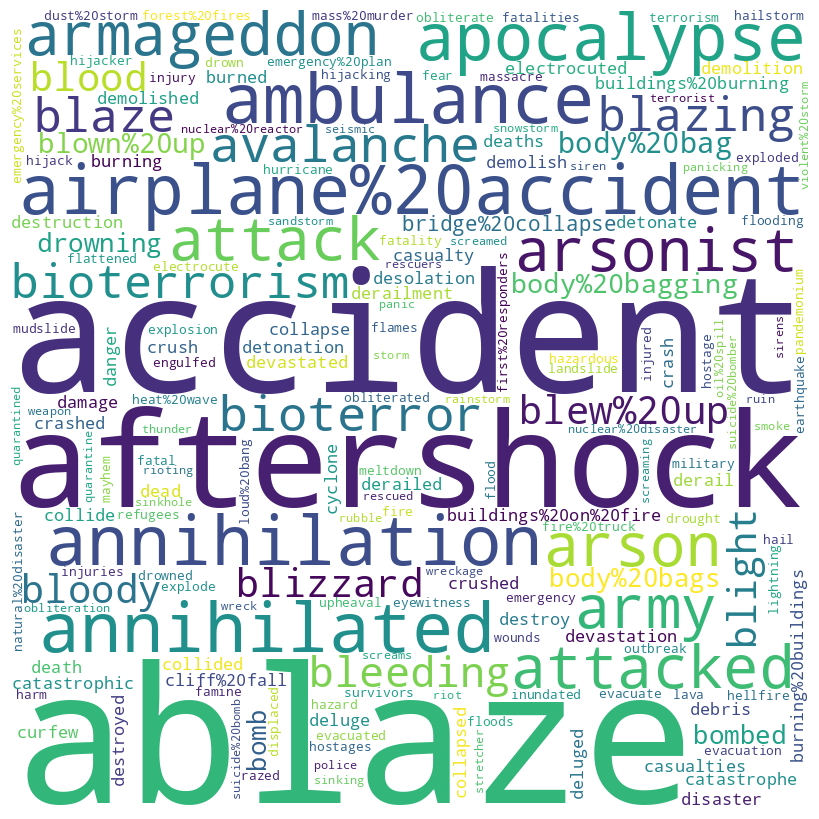

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Preencher valores NaN na coluna 'keyword' com uma string vazia para evitar erros
df_keywords = df['keyword'].fillna('')

# Contar a frequência de cada palavra-chave
keyword_frequencies = df_keywords.value_counts().to_dict()

# Remover a entrada para strings vazias se existir, pois não é uma palavra-chave real
if '' in keyword_frequencies:
    del keyword_frequencies['']

# Gerar a WordCloud
wordcloud = WordCloud(width = 800, height = 800,
                background_color ='white',
                min_font_size = 10).generate_from_frequencies(keyword_frequencies)

# Exibir a imagem gerada:
plt.figure(figsize = (8, 8), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)

plt.show()

tem algumas keyword que quebram com 20% = espaço

In [ ]:
# Criar uma cópia da coluna keyword com NaN preenchidos antes da correção para referência
df_keywords_original_state = df['keyword'].fillna('')

# Corrigir as keywords substituindo '%20' por um espaço no DataFrame principal
df['keyword'] = df['keyword'].str.replace('%20', ' ', regex=False)

print("Keywords corrigidas. Exemplos de palavras-chave que continham '%20':")

# Filtrar para mostrar apenas keywords que foram de fato modificadas
original_keywords_with_percent = [kw for kw in df_keywords_original_state.unique() if '%' in kw]

if original_keywords_with_percent:
    # Obter algumas palavras-chave originais que tinham '%' e suas versões corrigidas
    sample_size = min(5, len(original_keywords_with_percent))
    print(f"Exemplos de {sample_size} palavras-chave corrigidas:")
    for i in range(sample_size):
        original_kw = original_keywords_with_percent[i]
        # Tenta encontrar a versão corrigida no df atual, filtrando por keywords que contém a versão limpa do original
        # Certifica-se que a comparação é robusta mesmo se a keyword original com %20 não estiver exata na lista de uniques
        corrected_kw_search = df[df['keyword'].str.contains(original_kw.replace('%20', ' '), na=False)]['keyword']
        corrected_kw = corrected_kw_search.iloc[0] if not corrected_kw_search.empty else 'Não encontrado após correção'
        print(f"  Antes: '{original_kw}' -> Depois: '{corrected_kw}'")
else:
    print("Nenhuma palavra-chave com '%20' foi encontrada antes da correção.")

Keywords corrigidas. Exemplos de palavras-chave que continham '%20':
Exemplos de 5 palavras-chave corrigidas:
  Antes: 'airplane%20accident' -> Depois: 'airplane accident'
  Antes: 'blew%20up' -> Depois: 'blew up'
  Antes: 'blown%20up' -> Depois: 'blown up'
  Antes: 'body%20bag' -> Depois: 'body bag'
  Antes: 'body%20bagging' -> Depois: 'body bagging'


Consertei essas variáveis com quebra

In [ ]:
# Criar uma cópia do DataFrame para evitar SettingWithCopyWarning
df_check_new = df.copy()

# Preencher NaN na coluna 'keyword' com uma string vazia para facilitar a comparação
df_check_new['keyword'] = df_check_new['keyword'].fillna('')

# Converter 'text' e 'keyword' para minúsculas para uma comparação case-insensitive
df_check_new['text_lower'] = df_check_new['text'].str.lower()
df_check_new['keyword_lower'] = df_check_new['keyword'].str.lower()

# Verificar se a keyword (não vazia) está contida no texto
df_check_new['keyword_in_text'] = df_check_new.apply(
    lambda row: row['keyword_lower'] in row['text_lower'] if row['keyword_lower'] != '' else False,
    axis=1
)

# Contar o número de ocorrências onde a keyword está no text
num_keywords_in_text_new = df_check_new['keyword_in_text'].sum()
total_rows_with_keywords_new = df_check_new[df_check_new['keyword'] != ''].shape[0]


print(f"Número de keywords encontradas no texto (após correção): {num_keywords_in_text_new}")
print(f"Total de tweets com keyword (após correção): {total_rows_with_keywords_new}")

if total_rows_with_keywords_new > 0:
    percentage_new = (num_keywords_in_text_new / total_rows_with_keywords_new) * 100
    print(f"Porcentagem de keywords encontradas no texto (após correção): {percentage_new:.2f}%")
else:
    print("Não há tweets com keywords para verificar.")

# Limpar colunas temporárias
df_check_new.drop(columns=['text_lower', 'keyword_lower', 'keyword_in_text'], inplace=True)

Número de keywords encontradas no texto (após correção): 9581
Total de tweets com keyword (após correção): 10789
Porcentagem de keywords encontradas no texto (após correção): 88.80%


Vi de novo quantas keywords tem nos textos após consertar os que tem duas palavras

In [ ]:
import pandas as pd

# Preencher valores NaN na coluna 'keyword' com uma string vazia para evitar erros
df_keywords = df['keyword'].fillna('')

# Contar a frequência de cada palavra-chave
keyword_frequencies = df_keywords.value_counts()

# Remover a entrada para strings vazias se existir, pois não é uma palavra-chave real
if '' in keyword_frequencies:
    del keyword_frequencies['']

# Exibir as frequências
display(keyword_frequencies)

,count
keyword,
ablaze,50
accident,50
aftershock,50
airplane accident,50
ambulance,50
...,...
forest fire,24
threat,16
inundation,14


In [ ]:
# Filtrar as palavras-chave que aparecem apenas uma vez
keywords_once = keyword_frequencies[keyword_frequencies == 1]

# Verificar se há palavras-chave que aparecem apenas uma vez
if not keywords_once.empty:
    print(f"Sim, existem {len(keywords_once)} palavras-chave que aparecem apenas uma vez.")
    print("Palavras-chave que aparecem apenas uma vez:")
    display(keywords_once)
else:
    print("Não há palavras-chave que aparecem apenas uma vez.")

Não há palavras-chave que aparecem apenas uma vez.


In [ ]:
# Criar uma cópia do DataFrame para evitar SettingWithCopyWarning e manter o df original intacto
df_temp = df.copy()

# Preencher NaN na coluna 'keyword' para que possam ser agrupados
df_temp['keyword'] = df_temp['keyword'].fillna('no_keyword')

# Filtrar linhas onde 'target' é NaN, pois essas não têm um valor de desastre para calcular a taxa
df_temp_filtered = df_temp.dropna(subset=['target'])

# Calcular a taxa de 'target' (média de 1s) por keyword
keyword_target_rate = df_temp_filtered.groupby('keyword')['target'].mean().sort_values(ascending=False)

# Exibir as 20 principais keywords com maior taxa de desastre
print("Top 20 Keywords com maior taxa de desastre:")
display(keyword_target_rate.head(20))

print("\nTop 20 Keywords com menor taxa de desastre:")
display(keyword_target_rate.tail(20))

Top 20 Keywords com maior taxa de desastre:


,target
keyword,
debris,1.000000
derailment,1.000000
wreckage,1.000000
outbreak,0.975000
oil spill,0.973684
typhoon,0.973684
suicide bombing,0.969697
suicide bomber,0.967742
bombing,0.931034



Top 20 Keywords com menor taxa de desastre:


,target
keyword,
drown,0.093750
stretcher,0.090909
collide,0.088235
smoke,0.088235
bloody,0.085714
epicentre,0.083333
panic,0.081081
explode,0.078947
wrecked,0.076923


In [ ]:
# Criar uma cópia do DataFrame para evitar SettingWithCopyWarning
df_check_recreated = df.copy()

# Preencher NaN na coluna 'keyword' com uma string vazia para facilitar a comparação
df_check_recreated['keyword'] = df_check_recreated['keyword'].fillna('')

# Converter 'text' e 'keyword' para minúsculas para uma comparação case-insensitive
df_check_recreated['text_lower'] = df_check_recreated['text'].str.lower()
df_check_recreated['keyword_lower'] = df_check_recreated['keyword'].str.lower()

# Verificar se a keyword (não vazia) está contida no texto
df_check_recreated['keyword_in_text'] = df_check_recreated.apply(
    lambda row: row['keyword_lower'] in row['text_lower'] if row['keyword_lower'] != '' else False,
    axis=1
)

# Filtrar por linhas onde a keyword não está vazia e keyword_in_text é False
keyword_not_in_text_example = df_check_recreated[
    (df_check_recreated['keyword'] != '') &
    (df_check_recreated['keyword_in_text'] == False)
].sample(1)

if not keyword_not_in_text_example.empty:
    print("Exemplo de keyword que não está no texto:")
    display(keyword_not_in_text_example[['keyword', 'text']])
else:
    print("Não foi encontrado nenhum exemplo de keyword que não esteja no texto.")

# Limpar colunas temporárias após a análise
df_check_recreated.drop(columns=['text_lower', 'keyword_lower', 'keyword_in_text'], inplace=True)

Exemplo de keyword que não está no texto:


,keyword,text
9724,meltdown,CommoditiesåÊAre Crashing Like It's 2008 All O...


In [ ]:
# Criar uma cópia do DataFrame para evitar SettingWithCopyWarning
df_comparison = df.copy()

# Preencher NaN na coluna 'keyword' com uma string vazia para facilitar a comparação
df_comparison['keyword'] = df_comparison['keyword'].fillna('')

# Converter 'text' e 'keyword' para minúsculas para uma comparação case-insensitive
df_comparison['text_lower'] = df_comparison['text'].str.lower()
df_comparison['keyword_lower'] = df_comparison['keyword'].str.lower()

# Verificar se a keyword (não vazia) está contida no texto
df_comparison['keyword_in_text'] = df_comparison.apply(
    lambda row: row['keyword_lower'] in row['text_lower'] if row['keyword_lower'] != '' else False,
    axis=1
)

# Filtrar linhas onde 'target' não é NaN para calcular a taxa de desastre
df_comparison_filtered = df_comparison.dropna(subset=['target'])

# Separar os dados em dois grupos
keywords_in_text = df_comparison_filtered[df_comparison_filtered['keyword_in_text'] == True]
keywords_not_in_text = df_comparison_filtered[df_comparison_filtered['keyword_in_text'] == False]

# Calcular a taxa de desastre para cada grupo
rate_in_text = keywords_in_text['target'].mean()
rate_not_in_text = keywords_not_in_text['target'].mean()

print(f"Taxa de desastre para tweets com keyword no texto: {rate_in_text:.2f}")
print(f"Taxa de desastre para tweets com keyword NÃO no texto: {rate_not_in_text:.2f}")

# Limpar colunas temporárias
df_comparison.drop(columns=['text_lower', 'keyword_lower', 'keyword_in_text'], inplace=True)

Taxa de desastre para tweets com keyword no texto: 0.43
Taxa de desastre para tweets com keyword NÃO no texto: 0.43


a presença ou não de keywords no texto não é um diferencial

In [ ]:
# Criar uma cópia do DataFrame para evitar SettingWithCopyWarning
df_compound_analysis = df.copy()

# Preencher NaN na coluna 'keyword' com uma string vazia ou um marcador para não-keyword
df_compound_analysis['keyword'] = df_compound_analysis['keyword'].fillna('no_keyword')

# Criar uma nova coluna para indicar se a keyword é composta (contém espaço)
df_compound_analysis['is_compound'] = df_compound_analysis['keyword'].apply(lambda x: ' ' in x and x != 'no_keyword')

# Filtrar linhas onde 'target' não é NaN para calcular a taxa de desastre
df_compound_analysis_filtered = df_compound_analysis.dropna(subset=['target'])

# Calcular a taxa de desastre para keywords compostas e não compostas
compound_rate = df_compound_analysis_filtered[df_compound_analysis_filtered['is_compound'] == True]['target'].mean()
non_compound_rate = df_compound_analysis_filtered[df_compound_analysis_filtered['is_compound'] == False]['target'].mean()

print(f"Taxa de desastre para palavras-chave compostas: {compound_rate:.2f}")
print(f"Taxa de desastre para palavras-chave não compostas: {non_compound_rate:.2f}")

# Opcional: exibir a contagem para cada categoria também
print("\nContagem de keywords compostas e não compostas:")
display(df_compound_analysis_filtered.groupby('is_compound')['keyword'].count())

Taxa de desastre para palavras-chave compostas: 0.58
Taxa de desastre para palavras-chave não compostas: 0.40

Contagem de keywords compostas e não compostas:


,keyword
is_compound,
False,6448
True,1165


keywords compostas tem mais chance de serem relacionadas ao desastre

/tmp/ipython-input-1172641596.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Tipo de Keyword', y='Taxa de Desastre', data=df_rates, palette='viridis')


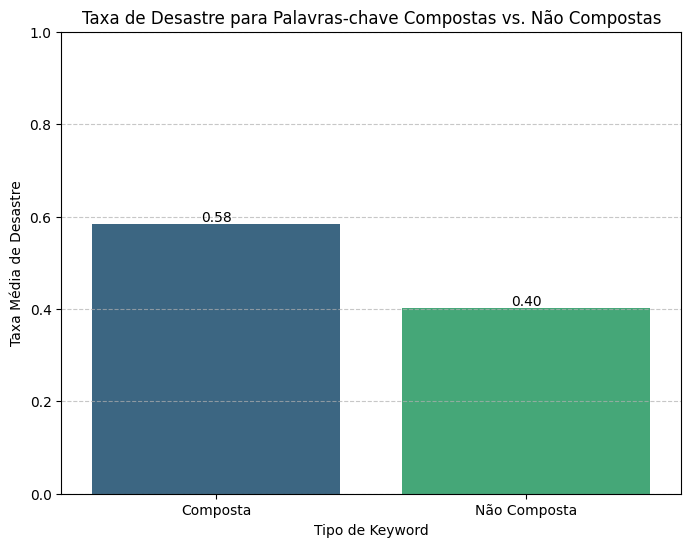

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Dados das taxas
data = {
    'Tipo de Keyword': ['Composta', 'Não Composta'],
    'Taxa de Desastre': [compound_rate, non_compound_rate]
}
df_rates = pd.DataFrame(data)

# Criar o gráfico de barras
plt.figure(figsize=(8, 6))
sns.barplot(x='Tipo de Keyword', y='Taxa de Desastre', data=df_rates, palette='viridis')
plt.title('Taxa de Desastre para Palavras-chave Compostas vs. Não Compostas')
plt.xlabel('Tipo de Keyword')
plt.ylabel('Taxa Média de Desastre')
plt.ylim(0, 1) # A taxa de desastre varia de 0 a 1
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionar os valores exatos nas barras
for index, row in df_rates.iterrows():
    plt.text(index, row['Taxa de Desastre'], f"{row['Taxa de Desastre']:.2f}", color='black', ha="center", va='bottom')

plt.show()

In [ ]:
# Preencher NaN na coluna 'keyword' com uma string vazia para não interferir na detecção de espaço
df['keyword_filled'] = df['keyword'].fillna('')

# Criar a nova feature 'Composta' como booleano
df['Composta'] = df['keyword_filled'].apply(lambda x: ' ' in x and x != '')

# Converter a feature 'Composta' para numérica (0 para False, 1 para True)
df['Composta'] = df['Composta'].astype(int)

# Opcional: Você pode remover a coluna 'keyword_filled' se não precisar dela
df.drop(columns=['keyword_filled'], inplace=True)

print("Nova feature 'Composta' criada no DataFrame (numérica):")
display(df.head())

Nova feature 'Composta' criada no DataFrame (numérica):


,id,keyword,location,text,target,Composta
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1.0,0
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1.0,0
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1.0,0
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1.0,0
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1.0,0


### Location

3638 nulos

In [ ]:
unique_locations_count = df['location'].nunique()
print(f"Número de valores únicos em 'location': {unique_locations_count}")

Número de valores únicos em 'location': 4521


meu deus, muito valores diferentes

In [ ]:
print("Frequência de valores em 'location':")
display(df['location'].value_counts())

Frequência de valores em 'location':


,count
location,
USA,141
New York,109
United States,65
London,58
Canada,42
...,...
"atl, ga",1
sam's town,1
#Kashmir,1


In [ ]:
get_ipython().system('pip install geonamescache')
get_ipython().system('pip install pycountry')
get_ipython().system('pip install geotext')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.0/32.0 MB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 23.8 MB/s eta 0:00:00


In [ ]:
import geonamescache as gc
import pycountry
from geotext import GeoText

print("Libraries geonamescache, pycountry, and GeoText from geotext imported successfully.")

Libraries geonamescache, pycountry, and GeoText from geotext imported successfully.


In [ ]:
gc_instance = gc.GeonamesCache()

continent_map = {
    'north america': 'North America', 'south america': 'South America',
    'europe': 'Europe', 'asia': 'Asia', 'africa': 'Africa', 'oceania': 'Oceania',
    'antartica': 'Antarctica',
    # Common country names often associated with continents that might appear in location text
    'united states': 'North America', 'canada': 'North America', 'mexico': 'North America',
    'brazil': 'South America', 'argentina': 'South America', 'colombia': 'South America', 'peru': 'South America', 'chile': 'South America',
    'united kingdom': 'Europe', 'germany': 'Europe', 'france': 'Europe', 'spain': 'Europe', 'italy': 'Europe',
    'china': 'Asia', 'india': 'Asia', 'japan': 'Asia', 'indonesia': 'Asia',
    'nigeria': 'Africa', 'south africa': 'Africa', 'egypt': 'Africa',
    'australia': 'Oceania', 'new zealand': 'Oceania'
}

def extract_continent_new(location_text):
    if not isinstance(location_text, str): # Handle non-string inputs
        return None
    location_text = location_text.lower()
    for term, continent in continent_map.items():
        if term in location_text:
            return continent
    return None

print("GeonamesCache initialized and extract_continent_new function defined.")

GeonamesCache initialized and extract_continent_new function defined.


In [ ]:
country_map = {
    'usa': 'United States', 'united states': 'United States', 'america': 'United States', 'us': 'United States',
    'uk': 'United Kingdom', 'united kingdom': 'United Kingdom', 'england': 'United Kingdom', 'britain': 'United Kingdom',
    'canada': 'Canada', 'australia': 'Australia', 'india': 'India', 'japan': 'Japan', 'germany': 'Germany',
    'france': 'France', 'brazil': 'Brazil', 'russia': 'Russia', 'china': 'China', 'mexico': 'Mexico',
    'spain': 'Spain', 'italy': 'Italy', 'nigeria': 'Nigeria', 'south africa': 'South Africa',
    'egypt': 'Egypt', 'philippines': 'Philippines', 'pakistan': 'Pakistan', 'indonesia': 'Indonesia',
    'new zealand': 'New Zealand', 'ireland': 'Ireland', 'uae': 'United Arab Emirates', 'switzerland': 'Switzerland',
    'sweden': 'Sweden', 'norway': 'Norway', 'denmark': 'Denmark', 'netherlands': 'Netherlands',
    'belgium': 'Belgium', 'austria': 'Austria', 'greece': 'Greece', 'portugal': 'Portugal',
    'finland': 'Finland', 'poland': 'Poland', 'turkey': 'Turkey', 'iran': 'Iran', 'iraq': 'Iraq',
    'syria': 'Syria', 'lebanon': 'Lebanon', 'jordan': 'Jordan', 'israel': 'Israel', 'palestine': 'Palestine',
    'afghanistan': 'Afghanistan', 'thailand': 'Thailand', 'vietnam': 'Vietnam', 'malaysia': 'Malaysia',
    'singapore': 'Singapore', 'korea': 'South Korea', 'south korea': 'South Korea', 'north korea': 'North Korea',
    'argentina': 'Argentina', 'colombia': 'Colombia', 'chile': 'Chile', 'peru': 'Peru',
    'venezuela': 'Venezuela', 'ecuador': 'Ecuador', 'bolivia': 'Bolivia', 'paraguay': 'Paraguay',
    'uruguay': 'Uruguay', 'africa': 'Africa' # General term, but can indicate country if specific one not found
}

def extract_country_new(location_text):
    if not isinstance(location_text, str):
        return None
    location_text = location_text.lower()

    # Check predefined map for common terms first
    for term, country_name in country_map.items():
        if term in location_text:
            return country_name

    # Use GeoText to extract country names
    places = GeoText(location_text)
    extracted_countries = places.countries

    if extracted_countries:
        # Validate against pycountry
        for country_code in extracted_countries:
            try:
                country = pycountry.countries.lookup(country_code)
                return country.name
            except LookupError:
                continue
    return None

print("extract_country_new function defined.")

extract_country_new function defined.


In [ ]:
state_map = {
    'alabama': 'Alabama', 'al': 'Alabama', 'alaska': 'Alaska', 'ak': 'Alaska',
    'arizona': 'Arizona', 'az': 'Arizona', 'arkansas': 'Arkansas', 'ar': 'Arkansas',
    'california': 'California', 'ca': 'California', 'colorado': 'Colorado', 'co': 'Colorado',
    'connecticut': 'Connecticut', 'ct': 'Connecticut', 'delaware': 'Delaware', 'de': 'Delaware',
    'florida': 'Florida', 'fl': 'Florida', 'georgia': 'Georgia', 'ga': 'Georgia',
    'hawaii': 'Hawaii', 'hi': 'Hawaii', 'idaho': 'Idaho', 'id': 'Idaho',
    'illinois': 'Illinois', 'il': 'Illinois', 'indiana': 'Indiana', 'in': 'Indiana',
    'iowa': 'Iowa', 'ia': 'Iowa', 'kansas': 'Kansas', 'ks': 'Kansas',
    'kentucky': 'Kentucky', 'ky': 'Kentucky', 'louisiana': 'Louisiana', 'la': 'Louisiana',
    'maine': 'Maine', 'me': 'Maine', 'maryland': 'Maryland', 'md': 'Maryland',
    'massachusetts': 'Massachusetts', 'ma': 'Massachusetts', 'michigan': 'Michigan', 'mi': 'Michigan',
    'minnesota': 'Minnesota', 'mn': 'Minnesota', 'mississippi': 'Mississippi', 'ms': 'Mississippi',
    'missouri': 'Missouri', 'mo': 'Missouri', 'montana': 'Montana', 'mt': 'Montana',
    'nebraska': 'Nebraska', 'ne': 'Nebraska', 'nevada': 'Nevada', 'nv': 'Nevada',
    'new hampshire': 'New Hampshire', 'nh': 'New Hampshire', 'new jersey': 'New Jersey', 'nj': 'New Jersey',
    'new mexico': 'New Mexico', 'nm': 'New Mexico', 'new york': 'New York', 'ny': 'New York',
    'north carolina': 'North Carolina', 'nc': 'North Carolina', 'north dakota': 'North Dakota', 'nd': 'North Dakota',
    'ohio': 'Ohio', 'oh': 'Ohio', 'oklahoma': 'Oklahoma', 'ok': 'Oklahoma',
    'oregon': 'Oregon', 'or': 'Oregon', 'pennsylvania': 'Pennsylvania', 'pa': 'Pennsylvania',
    'rhode island': 'Rhode Island', 'ri': 'Rhode Island', 'south carolina': 'South Carolina', 'sc': 'South Carolina',
    'south dakota': 'South Dakota', 'sd': 'South Dakota', 'tennessee': 'Tennessee', 'tn': 'Tennessee',
    'texas': 'Texas', 'tx': 'Texas', 'utah': 'Utah', 'ut': 'Utah',
    'vermont': 'Vermont', 'vt': 'Vermont', 'virginia': 'Virginia', 'va': 'Virginia',
    'washington': 'Washington', 'wa': 'Washington', 'west virginia': 'West Virginia', 'wv': 'West Virginia',
    'wisconsin': 'Wisconsin', 'wi': 'Wisconsin', 'wyoming': 'Wyoming', 'wy': 'Wyoming',

    # Canadian Provinces and Territories
    'alberta': 'Alberta', 'ab': 'Alberta', 'british columbia': 'British Columbia', 'bc': 'British Columbia',
    'manitoba': 'Manitoba', 'mb': 'Manitoba', 'new brunswick': 'New Brunswick', 'nb': 'New Brunswick',
    'newfoundland and labrador': 'Newfoundland and Labrador', 'nl': 'Newfoundland and Labrador',
    'nova scotia': 'Nova Scotia', 'ns': 'Nova Scotia', 'ontario': 'Ontario', 'on': 'Ontario',
    'prince Edward island': 'Prince Edward Island', 'pe': 'Prince Edward Island',
    'quebec': 'Quebec', 'qc': 'Quebec', 'saskatchewan': 'Saskatchewan', 'sk': 'Saskatchewan',
    'northwest territories': 'Northwest Territories', 'nt': 'Northwest Territories',
    'nunavut': 'Nunavut', 'nu': 'Nunavut', 'yukon': 'Yukon', 'yt': 'Yukon'
}

def extract_state_new(location_text, country_name=None):
    if not isinstance(location_text, str):
        return None
    location_text = location_text.lower()

    # Prioritize predefined state map
    for term, state_full_name in state_map.items():
        if term in location_text:
            return state_full_name

    # If a country is provided, try to look up subdivisions within that country
    if country_name:
        try:
            country_obj = pycountry.countries.lookup(country_name)
            for subdivision in pycountry.subdivisions.get(country_code=country_obj.alpha2):
                # Check full name, short name, and code
                if subdivision.name.lower() in location_text or \
                   subdivision.code.lower() in location_text or \
                   subdivision.name.split(',')[0].lower() in location_text: # Handle cases like 'California, U.S.'
                    return subdivision.name
        except LookupError:
            pass # Country not found in pycountry, or no subdivisions

    # Fallback to GeoText for extracting cities, then use geonamescache to find state
    # This is a less direct way but can catch some if direct state identification fails
    places = GeoText(location_text)
    cities_found = places.cities

    if cities_found:
        # Look up cities in geonamescache and extract state info
        # NOTE: This approach needs careful consideration as city names can be ambiguous
        for city_name in cities_found:
            cities_data = gc_instance.get_cities_by_name(city_name, case_sensitive=False)
            for city_info in cities_data:
                # Attempt to get state based on the associated country, if available
                if country_name and 'countrycode' in city_info and city_info['countrycode'] == country_obj.alpha2:
                    return city_info.get('admin1Code') # admin1Code often corresponds to state/province code
                elif not country_name:
                    return city_info.get('admin1Code')

    return None

print("extract_state_new function defined.")

extract_state_new function defined.


In [ ]:
def extract_city_new(location_text, country_name=None, state_name=None):
    if not isinstance(location_text, str):
        return None
    location_text = location_text.lower()

    places = GeoText(location_text)
    extracted_cities = places.cities

    if extracted_cities:
        for city_name in extracted_cities:
            # Try to get cities from geonamescache
            cities_data = gc_instance.get_cities_by_name(city_name, case_sensitive=False)

            # Filter by country and state if provided
            if country_name and state_name:
                country_code = None
                try:
                    country_code = pycountry.countries.lookup(country_name).alpha2
                except LookupError:
                    pass

                if country_code:
                    for city_info in cities_data:
                        if 'countrycode' in city_info and city_info['countrycode'] == country_code and \
                           'admin1Code' in city_info and city_info['admin1Code'] == state_name:
                            return city_info['name']

            elif country_name:
                country_code = None
                try:
                    country_code = pycountry.countries.lookup(country_name).alpha2
                except LookupError:
                    pass

                if country_code:
                    for city_info in cities_data:
                        if 'countrycode' in city_info and city_info['countrycode'] == country_code:
                            return city_info['name']

            elif state_name:
                # If only state is known, try to match admin1Code (might be ambiguous without country)
                for city_info in cities_data:
                    if 'admin1Code' in city_info and city_info['admin1Code'] == state_name:
                        return city_info['name']

            # If no country/state context, return the first validated city from geonamescache
            if cities_data:
                return cities_data[0]['name']
    return None

print("extract_city_new function defined.")

extract_city_new function defined.


In [ ]:
fictitious_terms = [
    'online', 'twitter', 'internet', 'web', 'worldwide', 'global', 'earth', 'universe',
    'everywhere', 'here', 'there', 'home', 'world', 'digital', 'virtual', 'mobile',
    'my home', 'your heart', 'hell', 'heaven', 'outer space', 'neverland', 'cyber space',
    'the void', 'dreamland', 'imagination', 'the web', 'the cloud', 'anywhere', 'unknown', 'na', ''
]

def is_fictitious_new(location_text):
    if not isinstance(location_text, str):
        return False
    location_text = location_text.lower()
    for term in fictitious_terms:
        if term and term in location_text:
            return True
    return False

print("is_fictitious_new function and fictitious_terms list defined.")

is_fictitious_new function and fictitious_terms list defined.


In [ ]:
state_map = {
    'alabama': 'Alabama', 'al': 'Alabama', 'alaska': 'Alaska', 'ak': 'Alaska',
    'arizona': 'Arizona', 'az': 'Arizona', 'arkansas': 'Arkansas', 'ar': 'Arkansas',
    'california': 'California', 'ca': 'California', 'colorado': 'Colorado', 'co': 'Colorado',
    'connecticut': 'Connecticut', 'ct': 'Connecticut', 'delaware': 'Delaware', 'de': 'Delaware',
    'florida': 'Florida', 'fl': 'Florida', 'georgia': 'Georgia', 'ga': 'Georgia',
    'hawaii': 'Hawaii', 'hi': 'Hawaii', 'idaho': 'Idaho', 'id': 'Idaho',
    'illinois': 'Illinois', 'il': 'Illinois', 'indiana': 'Indiana', 'in': 'Indiana',
    'iowa': 'Iowa', 'ia': 'Iowa', 'kansas': 'Kansas', 'ks': 'Kansas',
    'kentucky': 'Kentucky', 'ky': 'Kentucky', 'louisiana': 'Louisiana', 'la': 'Louisiana',
    'maine': 'Maine', 'me': 'Maine', 'maryland': 'Maryland', 'md': 'Maryland',
    'massachusetts': 'Massachusetts', 'ma': 'Massachusetts', 'michigan': 'Michigan', 'mi': 'Michigan',
    'minnesota': 'Minnesota', 'mn': 'Minnesota', 'mississippi': 'Mississippi', 'ms': 'Mississippi',
    'missouri': 'Missouri', 'mo': 'Missouri', 'montana': 'Montana', 'mt': 'Montana',
    'nebraska': 'Nebraska', 'ne': 'Nebraska', 'nevada': 'Nevada', 'nv': 'Nevada',
    'new hampshire': 'New Hampshire', 'nh': 'New Hampshire', 'new jersey': 'New Jersey', 'nj': 'New Jersey',
    'new mexico': 'New Mexico', 'nm': 'New Mexico', 'new york': 'New York', 'ny': 'New York',
    'north carolina': 'North Carolina', 'nc': 'North Carolina', 'north dakota': 'North Dakota', 'nd': 'North Dakota',
    'ohio': 'Ohio', 'oh': 'Ohio', 'oklahoma': 'Oklahoma', 'ok': 'Oklahoma',
    'oregon': 'Oregon', 'or': 'Oregon', 'pennsylvania': 'Pennsylvania', 'pa': 'Pennsylvania',
    'rhode island': 'Rhode Island', 'ri': 'Rhode Island', 'south carolina': 'South Carolina', 'sc': 'South Carolina',
    'south dakota': 'South Dakota', 'sd': 'South Dakota', 'tennessee': 'Tennessee', 'tn': 'Tennessee',
    'texas': 'Texas', 'tx': 'Texas', 'utah': 'Utah', 'ut': 'Utah',
    'vermont': 'Vermont', 'vt': 'Vermont', 'virginia': 'Virginia', 'va': 'Virginia',
    'washington': 'Washington', 'wa': 'Washington', 'west virginia': 'West Virginia', 'wv': 'West Virginia',
    'wisconsin': 'Wisconsin', 'wi': 'Wisconsin', 'wyoming': 'Wyoming', 'wy': 'Wyoming',

    # Canadian Provinces and Territories
    'alberta': 'Alberta', 'ab': 'Alberta', 'british columbia': 'British Columbia', 'bc': 'British Columbia',
    'manitoba': 'Manitoba', 'mb': 'Manitoba', 'new brunswick': 'New Brunswick', 'nb': 'New Brunswick',
    'newfoundland and labrador': 'Newfoundland and Labrador', 'nl': 'Newfoundland and Labrador',
    'nova scotia': 'Nova Scotia', 'ns': 'Nova Scotia', 'ontario': 'Ontario', 'on': 'Ontario',
    'prince Edward island': 'Prince Edward Island', 'pe': 'Prince Edward Island',
    'quebec': 'Quebec', 'qc': 'Quebec', 'saskatchewan': 'Saskatchewan', 'sk': 'Saskatchewan',
    'northwest territories': 'Northwest Territories', 'nt': 'Northwest Territories',
    'nunavut': 'Nunavut', 'nu': 'Nunavut', 'yukon': 'Yukon', 'yt': 'Yukon'
}

def extract_state_new(location_text, country_name=None):
    if not isinstance(location_text, str):
        return None
    location_text = location_text.lower()

    # Prioritize predefined state map
    for term, state_full_name in state_map.items():
        if term in location_text:
            return state_full_name

    # If a country is provided, try to look up subdivisions within that country
    if country_name:
        try:
            country_obj = pycountry.countries.lookup(country_name)
            if country_obj and hasattr(country_obj, 'alpha2'): # Ensure country_obj is valid and has alpha2
                for subdivision in pycountry.subdivisions.get(country_code=country_obj.alpha2):
                    # Check full name, short name, and code
                    if subdivision.name.lower() in location_text or \
                       subdivision.code.lower() in location_text or \
                       subdivision.name.split(',')[0].lower() in location_text:
                        return subdivision.name
        except LookupError:
            pass # Country not found in pycountry, or no subdivisions

    # Fallback to GeoText for extracting cities, then use geonamescache to find state
    places = GeoText(location_text)
    cities_found = places.cities

    if cities_found:
        for city_name in cities_found:
            cities_data = gc_instance.get_cities_by_name(city_name, case_sensitive=False)
            for city_info in cities_data:
                # Attempt to get state based on the associated country, if available
                if country_name and 'countrycode' in city_info:
                    try:
                        country_obj_for_city = pycountry.countries.lookup(country_name)
                        if country_obj_for_city and hasattr(country_obj_for_city, 'alpha2') and city_info['countrycode'] == country_obj_for_city.alpha2:
                            return city_info.get('admin1Code')
                    except LookupError:
                        pass
                elif not country_name and 'admin1Code' in city_info: # If no country, return any admin1Code
                    return city_info.get('admin1Code')

    return None

print("extract_state_new function defined.")

extract_state_new function defined.


In [ ]:
def extract_city_new(location_text, country_name=None, state_name=None):
    if not isinstance(location_text, str):
        return None
    location_text = location_text.lower()

    places = GeoText(location_text)
    extracted_cities = places.cities

    if extracted_cities:
        for city_name in extracted_cities:
            # Try to get cities from geonamescache
            cities_data = gc_instance.get_cities_by_name(city_name, case_sensitive=False)

            # Resolve country_code if country_name is provided
            country_code = None
            if country_name:
                try:
                    country_obj = pycountry.countries.lookup(country_name)
                    if country_obj and hasattr(country_obj, 'alpha2'):
                        country_code = country_obj.alpha2
                except LookupError:
                    pass

            # Filter by country and state if provided
            if country_code and state_name:
                for city_info in cities_data:
                    if 'countrycode' in city_info and city_info['countrycode'] == country_code and \
                       'admin1Code' in city_info and city_info['admin1Code'] == state_name:
                        return city_info['name']

            elif country_code:
                for city_info in cities_data:
                    if 'countrycode' in city_info and city_info['countrycode'] == country_code:
                        return city_info['name']

            elif state_name:
                # If only state is known, try to match admin1Code (might be ambiguous without country)
                for city_info in cities_data:
                    if 'admin1Code' in city_info and city_info['admin1Code'] == state_name:
                        return city_info['name']

            # If no country/state context, return the first validated city from geonamescache
            if cities_data:
                return cities_data[0]['name']
    return None

print("extract_city_new function redefined.")

extract_city_new function redefined.


In [ ]:
import numpy as np
import geonamescache as gc
import pycountry
from geotext import GeoText
import pandas as pd

# Initialize GeonamesCache (ensure this is done once globally or within the function for robustness)
gc_instance = gc.GeonamesCache()

# Maps countries to continents (used by get_continent_from_country_name)
country_to_continent_map = {
    'united states': 'North America', 'canada': 'North America', 'mexico': 'North America',
    'brazil': 'South America', 'argentina': 'South America', 'colombia': 'South America', 'peru': 'South America', 'chile': 'South America',
    'united kingdom': 'Europe', 'germany': 'Europe', 'france': 'Europe', 'spain': 'Europe', 'italy': 'Europe', 'portugal': 'Europe', 'netherlands': 'Europe', 'belgium': 'Europe', 'switzerland': 'Europe', 'sweden': 'Europe', 'norway': 'Europe', 'denmark': 'Europe', 'finland': 'Europe', 'austria': 'Europe', 'greece': 'Europe', 'poland': 'Europe', 'ukraine': 'Europe', 'romania': 'Europe', 'hungary': 'Europe', 'czech republic': 'Europe', 'slovakia': 'Europe',
    'india': 'Asia', 'japan': 'Asia', 'china': 'Asia', 'philippines': 'Asia', 'indonesia': 'Asia', 'pakistan': 'Asia', 'thailand': 'Asia', 'vietnam': 'Asia', 'malaysia': 'Asia',
    'nigeria': 'Africa', 'south africa': 'Africa', 'egypt': 'Africa', 'kenya': 'Africa', 'ghana': 'Africa', 'gambia': 'Africa',
    'australia': 'Oceania', 'new zealand': 'Oceania',
    'united arab emirates': 'Asia', 'qatar': 'Asia', 'singapore': 'Asia',
    'iran': 'Asia', 'iraq': 'Asia', 'saudi arabia': 'Asia',
    'venezuela': 'South America', 'ecuador': 'South America', 'bolivia': 'South America', 'paraguay': 'South America', 'uruguay': 'South America',
}

# Explicit list of continent names for direct matching as a last resort
direct_continent_names_lookup = {
    'north america': 'North America', 'south america': 'South America',
    'europe': 'Europe', 'asia': 'Asia', 'africa': 'Africa', 'oceania': 'Oceania',
    'antartica': 'Antarctica'
}

# Comprehensive country map including common terms (from original country_map_lookup)
country_map_lookup = {
    'usa': 'United States', 'united states': 'United States', 'america': 'United States', 'us': 'United States',
    'uk': 'United Kingdom', 'united kingdom': 'United Kingdom', 'england': 'United Kingdom', 'britain': 'United Kingdom',
    'canada': 'Canada', 'australia': 'Australia', 'india': 'India', 'japan': 'Japan', 'germany': 'Germany',
    'france': 'France', 'brazil': 'Brazil', 'russia': 'Russia', 'china': 'China', 'mexico': 'Mexico',
    'spain': 'Spain', 'italy': 'Italy', 'nigeria': 'Nigeria', 'south africa': 'South Africa',
    'egypt': 'Egypt', 'philippines': 'Philippines', 'pakistan': 'Pakistan', 'indonesia': 'Indonesia',
    'new zealand': 'New Zealand', 'ireland': 'Ireland', 'uae': 'United Arab Emirates', 'switzerland': 'Switzerland',
    'sweden': 'Sweden', 'norway': 'Norway', 'denmark': 'Denmark', 'netherlands': 'Netherlands',
    'belgium': 'Belgium', 'austria': 'Austria', 'greece': 'Greece', 'portugal': 'Portugal',
    'finland': 'Finland', 'poland': 'Poland', 'turkey': 'Turkey', 'iran': 'Iran', 'iraq': 'Iraq',
    'syria': 'Syria', 'lebanon': 'Lebanon', 'jordan': 'Jordan', 'israel': 'Israel', 'palestine': 'Palestine',
    'afghanistan': 'Afghanistan', 'thailand': 'Thailand', 'vietnam': 'Vietnam', 'malaysia': 'Malaysia',
    'singapore': 'Singapore', 'korea': 'South Korea', 'south korea': 'South Korea', 'north korea': 'North Korea',
    'argentina': 'Argentina', 'colombia': 'Colombia', 'chile': 'Chile', 'peru': 'Peru',
    'venezuela': 'Venezuela', 'ecuador': 'Ecuador', 'bolivia': 'Bolivia', 'paraguay': 'Paraguay',
    'uruguay': 'Uruguay', 'africa': 'Africa' # General term, but can indicate country if specific one not found
}

# State map (from original state_map_lookup)
state_map_lookup = {
    'alabama': 'Alabama', 'al': 'Alabama', 'alaska': 'Alaska', 'ak': 'Alaska', 'arizona': 'Arizona', 'az': 'Arizona',
    'california': 'California', 'ca': 'California', 'new york': 'New York', 'ny': 'New York', 'texas': 'Texas', 'tx': 'Texas',
    'florida': 'Florida', 'fl': 'Florida', 'illinois': 'Illinois', 'il': 'Illinois', 'ontario': 'Ontario', 'on': 'Ontario',
    'quebec': 'Quebec', 'qc': 'Quebec', 'british columbia': 'British Columbia', 'bc': 'British Columbia',
    'lagos': 'Lagos', 'kano': 'Kano', 'rivers': 'Rivers', 'oyo': 'Oyo', 'ogun': 'Ogun', # Nigeria
    'andalusia': 'Andalusia', 'catalonia': 'Catalonia', 'madrid': 'Community of Madrid', 'valencia': 'Valencian Community', 'galicia': 'Galicia', # Spain
    'bavaria': 'Bavaria', 'nrw': 'North Rhine-Westphalia', 'berlin': 'Berlin', 'hesse': 'Hesse', 'saxony': 'Saxony', # Germany
    'maharashtra': 'Maharashtra', 'uttar pradesh': 'Uttar Pradesh', 'delhi': 'Delhi', 'karnataka': 'Karnataka', 'tamil nadu': 'Tamil Nadu', # India
    'jakarta': 'Jakarta', 'west java': 'West Java', 'east java': 'East Java', 'north sumatra': 'North Sumatra', 'central java': 'Central Java', # Indonesia
    'ncr': 'National Capital Region', 'calabarzon': 'CALABARZON', 'central luzon': 'Central Luzon', 'cebu': 'Cebu', 'davao region': 'Davao Region' # Philippines
}

fictitious_terms_global = [
    'online', 'twitter', 'internet', 'web', 'worldwide', 'global', 'earth', 'universe',
    'everywhere', 'here', 'there', 'home', 'world', 'digital', 'virtual', 'mobile',
    'my home', 'your heart', 'hell', 'heaven', 'outer space', 'neverland', 'cyber space',
    'the void', 'dreamland', 'imagination', 'the web', 'the cloud', 'anywhere', 'unknown', 'na', ''
]

def get_country_from_geonames_code(country_code):
    if not country_code: return None
    try:
        country_obj = pycountry.countries.get(alpha_2=country_code)
        return country_obj.name if country_obj else None
    except KeyError:
        return None

def get_state_from_geonames_codes(country_code, admin1_code):
    if not country_code or not admin1_code: return None
    try:
        # pycountry uses codes like 'US-CA'. admin1Code from geonames is 'CA'.
        # Need to check for both 'country_code-admin1Code' and direct admin1Code match if its a full name
        subdivisions = pycountry.subdivisions.get(country_code=country_code)
        for sub in subdivisions:
            if sub.code == f"{country_code}-{admin1_code}" or sub.name.lower() == admin1_code.lower():
                return sub.name
        return None
    except KeyError: # Country not in pycountry or no subdivisions
        return None

def get_continent_from_country_name(country_name):
    if not country_name: return None
    return country_to_continent_map.get(country_name.lower(), None)


def extract_all_geo_info(location_text):
    city, state, country, continent = None, None, None, None

    if not isinstance(location_text, str) or location_text.strip() == '':
        return None, None, None, None, 1 # Mark as fictitious if empty/non-string

    location_text_lower = location_text.lower()

    # 0. Check for fictitious terms first
    if any(term in location_text_lower for term in fictitious_terms_global if term != ''):
        return None, None, None, None, 1 # Clearly fictitious

    # 1. Try to extract City and infer hierarchy using GeoText and GeoNamesCache
    places = GeoText(location_text) # Use original location_text for GeoText for better entity recognition
    extracted_cities = places.cities
    if extracted_cities:
        for city_name_found in extracted_cities:
            # Removed case_sensitive=False as it causes TypeError
            cities_data = gc_instance.get_cities_by_name(city_name_found)
            if cities_data:
                city_info = cities_data[0] # Take the first, most relevant match (can be improved with better selection)
                city = city_info.get('name')
                country_code_from_city = city_info.get('countrycode')
                admin1_code_from_city = city_info.get('admin1Code')

                country = get_country_from_geonames_code(country_code_from_city)
                state = get_state_from_geonames_codes(country_code_from_city, admin1_code_from_city)
                continent = get_continent_from_country_name(country)

                if city: # If a city was identified, we've found the most granular info
                    return continent, country, state, city, 0

    # 2. If no City, try to extract State and infer hierarchy
    # Try predefined state map first (e.g. 'california' -> 'California')
    for term_state, state_full_name in state_map_lookup.items():
        if term_state in location_text_lower:
            state = state_full_name
            # Attempt to find country from text, then use pycountry for state validation and continent inference
            potential_country_name = None
            for term_country, country_name_map in country_map_lookup.items():
                if term_country in location_text_lower:
                    potential_country_name = country_name_map
                    break

            if potential_country_name:
                try:
                    country_obj = pycountry.countries.lookup(potential_country_name)
                    if country_obj and hasattr(country_obj, 'alpha2'):
                        # Validate if the state truly belongs to this country
                        subdivisions = pycountry.subdivisions.get(country_code=country_obj.alpha2)
                        if subdivisions and any(sub.name == state_full_name for sub in subdivisions):
                            country = potential_country_name
                            continent = get_continent_from_country_name(country)
                            return continent, country, state, None, 0
                except LookupError:
                    pass
            # If state found but no country or no valid country-state pair, still return state if it's strong
            else: # If no explicit country matched in text, still try to get continent if state implies country
                # This is a weak link, but better than nothing. E.g., 'Lagos' is often Nigeria
                for country_name, cont in country_to_continent_map.items():
                    if state_full_name.lower() == country_name.lower(): # e.g. 'Lagos' could imply 'Nigeria'
                        country = country_name
                        continent = cont
                        return continent, country, state, None, 0
                return None, None, state, None, 0 # Return state without country/continent if inference fails

    # 3. If no State, try to extract Country directly
    for term_country, country_name_found in country_map_lookup.items():
        if term_country in location_text_lower:
            country = country_name_found
            continent = get_continent_from_country_name(country)
            return continent, country, None, None, 0

    # 4. If no Country, try to match a direct Continent name from the text
    for term_continent, continent_name_found in direct_continent_names_lookup.items():
        if term_continent in location_text_lower:
            continent = continent_name_found
            return continent, None, None, None, 0

    # If nothing specific is found, it's 'Unknown' and considered fictitious by default
    return None, None, None, None, 1

# 1. Create a new column named `location_cleaned` (if not already created)
df['location_cleaned'] = df['location'].astype(str).fillna('')

# Apply the new hierarchical parsing function
# The .apply(lambda x: pd.Series(func(x))) pattern is useful here.
results_df = df['location_cleaned'].apply(lambda x: pd.Series(extract_all_geo_info(x), index=['Continente', 'País', 'Estado', 'Cidade', 'Fictício']))

# Assign the results to the new columns in the main DataFrame
df['Continente'] = results_df['Continente']
df['País'] = results_df['País']
df['Estado'] = results_df['Estado']
df['Cidade'] = results_df['Cidade']
df['Fictício'] = results_df['Fictício']

# Also create Fictício_bin for consistency with original notebook flow (assuming Fictício is already 0 or 1)
df['Fictício_bin'] = df['Fictício']

print("New hierarchical geographical features created.")
display(df[['location', 'location_cleaned', 'Continente', 'País', 'Estado', 'Cidade', 'Fictício']].head())

New hierarchical geographical features created.


,location,location_cleaned,Continente,País,Estado,Cidade,Fictício
0,NaN,nan,NaN,NaN,NaN,NaN,1.0
1,NaN,nan,NaN,NaN,NaN,NaN,1.0
2,NaN,nan,NaN,NaN,NaN,NaN,1.0
3,NaN,nan,NaN,NaN,NaN,NaN,1.0
4,NaN,nan,NaN,NaN,NaN,NaN,1.0


In [ ]:
print("First few rows with new location features:")
display(df[['location', 'location_cleaned', 'Continente', 'País', 'Estado', 'Cidade', 'Fictício']].head())

print("\nValue Counts for Continente:")
display(df['Continente'].value_counts(dropna=False))

print("\nValue Counts for País:")
display(df['País'].value_counts(dropna=False))

print("\nValue Counts for Estado:")
display(df['Estado'].value_counts(dropna=False))

print("\nContagem de valores para 'Cidade':")
display(df['Cidade'].value_counts(dropna=False))

print("\nContagem de valores para 'Fictício':")
display(df['Fictício'].value_counts(dropna=False))

First few rows with new location features:


,location,location_cleaned,Continente,País,Estado,Cidade,Fictício
0,NaN,nan,NaN,NaN,NaN,NaN,1.0
1,NaN,nan,NaN,NaN,NaN,NaN,1.0
2,NaN,nan,NaN,NaN,NaN,NaN,1.0
3,NaN,nan,NaN,NaN,NaN,NaN,1.0
4,NaN,nan,NaN,NaN,NaN,NaN,1.0



Value Counts for Continente:


,count
Continente,
NaN,6904
None,2447
North America,743
Europe,407
Asia,219
Africa,108
South America,34
Oceania,14



Value Counts for País:


...

,count
Estado,
NaN,6904
None,1590
Ontario,577
Alabama,478
California,350
New York,345
Illinois,229
Florida,111
Texas,98



Contagem de valores para 'Cidade':


,count
Cidade,
NaN,10876



Contagem de valores para 'Fictício':


,count
Fictício,
1.0,6904
0.0,3972


In [ ]:
import pandas as pd

# Re-load df if it's not defined (fallback for kernel resets or out-of-order execution)
if 'df' not in locals():
    # Corrected paths with proper characters
    caminho = '/content/drive/Shareddrives/Rede CC/Rede CC 2.0/1. Áreas/2. Escola de Negócios/4. CCTech/2. Período de Capacitação/11. NLP/João Paulo/train (2).csv'
    df_1=pd.read_csv(caminho)
    caminho2 = '/content/drive/Shareddrives/Rede CC/Rede CC 2.0/1. Áreas/2. Escola de Negócios/4. CCTech/2. Período de Capacitação/11. NLP/João Paulo/test (2).csv'
    df_2=pd.read_csv(caminho2)
    df = pd.concat([df_1, df_2], ignore_index=True)

# Define the list of geographical columns that should exist
required_geographical_cols = ['location_cleaned', 'Continente', 'País', 'Estado', 'Cidade', 'Fictício']

# Check if all required columns are present in df
missing_cols = [col for col in required_geographical_cols if col not in df.columns]

if missing_cols:
    print(f"Erro: As seguintes colunas geográficas necessárias estão faltando no DataFrame: {', '.join(missing_cols)}.")
    print("Por favor, execute a célula 'ded61e76' para criar essas colunas antes de executar esta célula.")
else:
    print("Primeiras linhas do DataFrame com as features geográficas:")
    display(df[['location', 'location_cleaned', 'Continente', 'País', 'Estado', 'Cidade', 'Fictício']].head())

    print("\nContagem de valores para 'Continente':")
    display(df['Continente'].value_counts(dropna=False))

    print("\nContagem de valores para 'País':")
    display(df['País'].value_counts(dropna=False))

    print("\nContagem de valores para 'Estado':")
    display(df['Estado'].value_counts(dropna=False))

    print("\nContagem de valores para 'Cidade':")
    display(df['Cidade'].value_counts(dropna=False))

    print("\nContagem de valores para 'Fictício':")
    display(df['Fictício'].value_counts(dropna=False))

Primeiras linhas do DataFrame com as features geográficas:


,location,location_cleaned,Continente,País,Estado,Cidade,Fictício
0,NaN,nan,Unknown,Unknown,Unknown,Unknown,1
1,NaN,nan,Unknown,Unknown,Unknown,Unknown,1
2,NaN,nan,Unknown,Unknown,Unknown,Unknown,1
3,NaN,nan,Unknown,Unknown,Unknown,Unknown,1
4,NaN,nan,Unknown,Unknown,Unknown,Unknown,1



Contagem de valores para 'Continente':


,count
Continente,
Unknown,10517
North America,280
Europe,41
Asia,18
Africa,10
Oceania,5
South America,4
Sweden,1



Contagem de valores para 'País':


...

,count
Estado,
Unknown,5427
Alabama,726
Arkansas,472
Indiana,446
Oregon,395
Louisiana,335
Iowa,307
Hawaii,292
Colorado,231



Contagem de valores para 'Cidade':


,count
Cidade,
Unknown,10805
London,10
Los Angeles,6
New York,5
Washington,5
Dallas,5
Mumbai,4
Seattle,3
Toronto,3



Contagem de valores para 'Fictício':


,count
Fictício,
1,5843
0,5033


Taxa de Desastre por Continente:


,target
Continente,
Africa,0.662500
Asia,0.590604
North America,0.489681
Europe,0.445578
Oceania,0.428571
South America,0.304348


/tmp/ipython-input-945421783.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=continent_disaster_rate.index, y=continent_disaster_rate.values, palette='viridis')


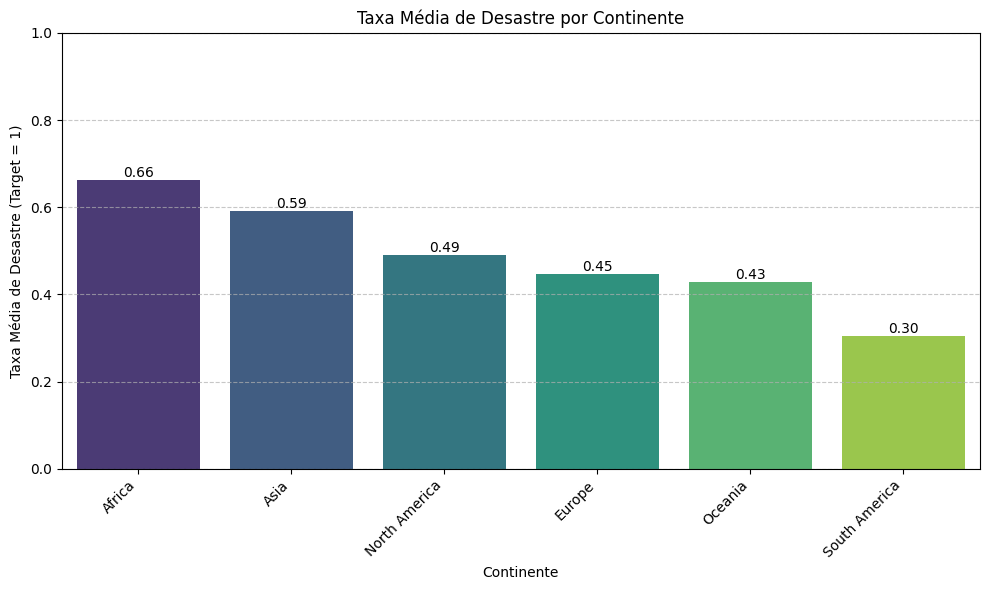

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter the DataFrame to include only the rows with 'target' not null for analysis
df_filtered_target = df.dropna(subset=['target']).copy()

# Calculate the disaster rate (mean of 'target') for each continent
continent_disaster_rate = df_filtered_target.groupby('Continente')['target'].mean().sort_values(ascending=False)

print("Taxa de Desastre por Continente:")
display(continent_disaster_rate)

# Plotting the disaster rate by continent
plt.figure(figsize=(10, 6))
sns.barplot(x=continent_disaster_rate.index, y=continent_disaster_rate.values, palette='viridis')
plt.title('Taxa Média de Desastre por Continente')
plt.xlabel('Continente')
plt.ylabel('Taxa Média de Desastre (Target = 1)')
plt.ylim(0, 1) # Target is a binary variable, so rate is between 0 and 1
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add the values on top of the bars for clarity
for index, value in enumerate(continent_disaster_rate.values):
    plt.text(index, value, f"{value:.2f}", color='black', ha="center", va='bottom')

plt.tight_layout()
plt.show()

Top 10 Estados com maior taxa de desastre (min. 10 tweets):


,target
Estado,
Arizona,0.571429
Alabama,0.483483
Alaska,0.457627
California,0.428000
Ontario,0.422705
Illinois,0.394118
British Columbia,0.363636
Florida,0.337662
New York,0.316456



Top 10 Estados com menor taxa de desastre (min. 10 tweets, excluindo 'Unknown' se presente):


,target
Estado,
Arizona,0.571429
Alabama,0.483483
Alaska,0.457627
California,0.428000
Ontario,0.422705
Illinois,0.394118
British Columbia,0.363636
Florida,0.337662
New York,0.316456


/tmp/ipython-input-4168733244.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_disaster_rate.head(10).index, y=state_disaster_rate.head(10).values, palette='viridis')


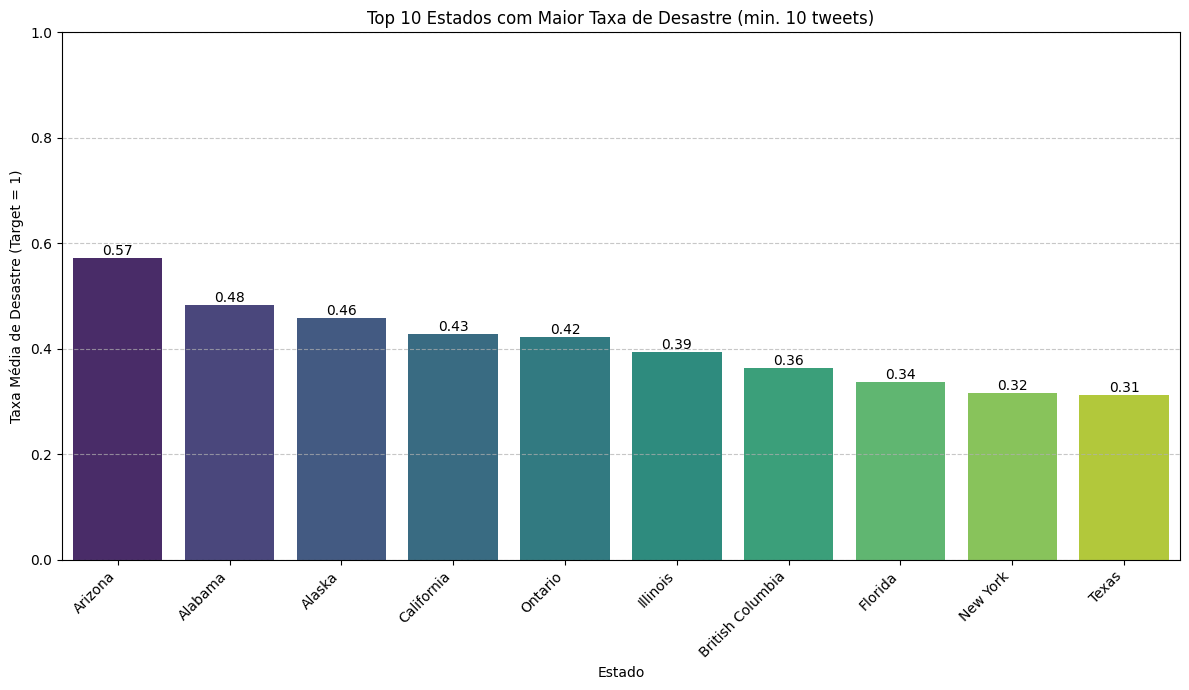

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter the DataFrame to include only the rows with 'target' not null for analysis
df_filtered_target = df.dropna(subset=['target']).copy()

# Calculate the count of tweets per state
state_tweet_counts = df_filtered_target['Estado'].value_counts()

# Identify states with at least 10 tweets
states_with_min_tweets = state_tweet_counts[state_tweet_counts >= 10].index

# Filter the DataFrame to include only these states
df_filtered_by_state_count = df_filtered_target[df_filtered_target['Estado'].isin(states_with_min_tweets)]

# Calculate the disaster rate (mean of 'target') for these filtered states
state_disaster_rate = df_filtered_by_state_count.groupby('Estado')['target'].mean().sort_values(ascending=False)

print("Top 10 Estados com maior taxa de desastre (min. 10 tweets):")
display(state_disaster_rate.head(10))

print("\nTop 10 Estados com menor taxa de desastre (min. 10 tweets, excluindo 'Unknown' se presente):")
display(state_disaster_rate[state_disaster_rate.index != 'Unknown'].tail(10))

# Plotting the top 10 states
plt.figure(figsize=(12, 7))
sns.barplot(x=state_disaster_rate.head(10).index, y=state_disaster_rate.head(10).values, palette='viridis')
plt.title('Top 10 Estados com Maior Taxa de Desastre (min. 10 tweets)')
plt.xlabel('Estado')
plt.ylabel('Taxa Média de Desastre (Target = 1)')
plt.ylim(0, 1) # Target is a binary variable, so rate is between 0 and 1
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add the values on top of the bars for clarity
for index, value in enumerate(state_disaster_rate.head(10).values):
    plt.text(index, value, f"{value:.2f}", color='black', ha="center", va='bottom')

plt.tight_layout()
plt.show()

### Text e Modelo

Preparar para o modelo DistilBERT, que consiste em um modelo de linguagem criado pelo Google, que entende texto analisando o contexto antes e depois de cada palavra, chamdado de contextualização bidirecional.

Este o modelo parecido com o BERT, mas 40% menor e 60% mais rápido com quase a mesma qualidade, usando um processo de distilação, em que esse grande modelo o 'BERT' ensina o modelo menor. É como uma comprimir o conhecimento do BERT, usando:
- Soft targets
- Perda de linguagem mascarada
- Perda de alinhamento das representações internas

Imagina que o BERT é o professor e o DistilBERT é o aluno

In [ ]:
pip install transformers

In [ ]:
pip install torch

In [ ]:
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification

In [ ]:
from torch.optim import AdamW

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
df_train_only = df.dropna(subset=['target']).copy()
print("Sub-DataFrame 'df_train_only' created with non-null 'target' values.")

Sub-DataFrame 'df_train_only' created with non-null 'target' values.


In [ ]:
X = df_train_only['text']
y = df_train_only['target']
print("Features (X) and target (y) defined from df_train_only.")

Features (X) and target (y) defined from df_train_only.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Data split into training and testing sets successfully.")

Data split into training and testing sets successfully.


In [ ]:
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

X_train_tokenized = tokenizer(list(X_train.values), padding='max_length', truncation=True, max_length=128, return_tensors='pt')
X_test_tokenized = tokenizer(list(X_test.values), padding='max_length', truncation=True, max_length=128, return_tensors='pt')

print("DistilBERT tokenizer loaded and data tokenized successfully.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

DistilBERT tokenizer loaded and data tokenized successfully.


In [ ]:
X_train_input_ids = X_train_tokenized['input_ids']
X_train_attention_mask = X_train_tokenized['attention_mask']

X_test_input_ids = X_test_tokenized['input_ids']
X_test_attention_mask = X_test_tokenized['attention_mask']

print("Input IDs and Attention Masks extracted successfully.")
print(f"Shape of X_train_input_ids: {X_train_input_ids.shape}")
print(f"Shape of X_train_attention_mask: {X_train_attention_mask.shape}")
print(f"Shape of X_test_input_ids: {X_test_input_ids.shape}")
print(f"Shape of X_test_attention_mask: {X_test_attention_mask.shape}")

Input IDs and Attention Masks extracted successfully.
Shape of X_train_input_ids: torch.Size([6090, 128])
Shape of X_train_attention_mask: torch.Size([6090, 128])
Shape of X_test_input_ids: torch.Size([1523, 128])
Shape of X_test_attention_mask: torch.Size([1523, 128])


In [ ]:
import torch
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

print("Target variables converted to PyTorch tensors successfully.")
print(f"Shape of y_train_tensor: {y_train_tensor.shape}")
print(f"Shape of y_test_tensor: {y_test_tensor.shape}")

Target variables converted to PyTorch tensors successfully.
Shape of y_train_tensor: torch.Size([6090])
Shape of y_test_tensor: torch.Size([1523])


**Reasoning**:
To prepare the data for training a DistilBERT model, I will convert the tokenized inputs and the target labels into `TensorDataset` objects and then create `DataLoader` objects for both the training and testing sets, enabling batch processing as specified in the instructions.



In [ ]:
from torch.utils.data import TensorDataset, DataLoader

batch_size = 32

# Create TensorDataset for training data
train_dataset = TensorDataset(X_train_input_ids, X_train_attention_mask, y_train_tensor)

# Create TensorDataset for test data
test_dataset = TensorDataset(X_test_input_ids, X_test_attention_mask, y_test_tensor)

# Create DataLoader for training data
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Create DataLoader for test data
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("TensorDatasets and DataLoaders created successfully.")
print(f"Number of batches in train_dataloader: {len(train_dataloader)}")
print(f"Number of batches in test_dataloader: {len(test_dataloader)}")

TensorDatasets and DataLoaders created successfully.
Number of batches in train_dataloader: 191
Number of batches in test_dataloader: 48


### Carregar Modelo DistilBERT para Classificação




In [ ]:
model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)
print("DistilBERT model for sequence classification loaded successfully.")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


DistilBERT model for sequence classification loaded successfully.


In [ ]:
optimizer = AdamW(model.parameters(), lr=5e-5)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

print(f"Optimizer AdamW configured with learning rate 5e-5.")
print(f"Model moved to device: {device}")

Optimizer AdamW configured with learning rate 5e-5.
Model moved to device: cpu


In [ ]:
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Set the model to training mode
model.train()

epochs = 3 # Define the number of epochs for training

for epoch in range(epochs):
    print(f"\n--- Epoch {epoch + 1}/{epochs} ---")
    total_train_loss = 0
    total_train_correct = 0
    total_train_samples = 0

    # Training loop
    for batch in train_dataloader:
        input_ids, attention_mask, labels = batch

        # Move batch to device
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels = labels.to(device)

        # Clear gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        logits = outputs.logits

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

        # Calculate training accuracy
        preds = torch.argmax(logits, dim=1)
        total_train_correct += (preds == labels).sum().item()
        total_train_samples += labels.size(0)

    avg_train_loss = total_train_loss / len(train_dataloader)
    train_accuracy = total_train_correct / total_train_samples
    print(f"Training Loss: {avg_train_loss:.4f}, Training Accuracy: {train_accuracy:.4f}")

    # Evaluation loop
    model.eval() # Set model to evaluation mode
    total_test_loss = 0
    true_labels = []
    predicted_labels = []

    with torch.no_grad(): # Disable gradient calculations
        for batch in test_dataloader:
            input_ids, attention_mask, labels = batch

            # Move batch to device
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            logits = outputs.logits

            total_test_loss += loss.item()

            # Get predictions
            preds = torch.argmax(logits, dim=1)
            true_labels.extend(labels.cpu().numpy())
            predicted_labels.extend(preds.cpu().numpy())

    avg_test_loss = total_test_loss / len(test_dataloader)
    test_accuracy = accuracy_score(true_labels, predicted_labels)
    test_precision = precision_score(true_labels, predicted_labels, average='binary')
    test_recall = recall_score(true_labels, predicted_labels, average='binary')
    test_f1 = f1_score(true_labels, predicted_labels, average='binary')

    print(f"Test Loss: {avg_test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"Test Precision: {test_precision:.4f}")
    print(f"Test Recall: {test_recall:.4f}")
    print(f"Test F1-Score: {test_f1:.4f}")

print("\nTraining and evaluation loop finished.")


--- Epoch 1/3 ---
Training Loss: 0.4482, Training Accuracy: 0.7989
Test Loss: 0.3819
Test Accuracy: 0.8424
Test Precision: 0.8739
Test Recall: 0.7365
Test F1-Score: 0.7993

--- Epoch 2/3 ---
Training Loss: 0.2931, Training Accuracy: 0.8826
Test Loss: 0.3907
Test Accuracy: 0.8523
Test Precision: 0.8655
Test Recall: 0.7735
Test F1-Score: 0.8169

--- Epoch 3/3 ---
Training Loss: 0.1467, Training Accuracy: 0.9437
Test Loss: 0.5034
Test Accuracy: 0.8352
Test Precision: 0.8373
Test Recall: 0.7612
Test F1-Score: 0.7974

Training and evaluation loop finished.


In [ ]:
import torch
import pandas as pd
from torch.utils.data import TensorDataset, DataLoader

# 1. Identificar os dados de teste (onde 'target' é NaN)
df_test_kaggle = df[df['target'].isnull()].copy()

X_kaggle_test = df_test_kaggle['text']
id_kaggle_test = df_test_kaggle['id']

# 2. Preparar os dados de teste: Tokenizar
X_kaggle_test_tokenized = tokenizer(list(X_kaggle_test.values), padding='max_length', truncation=True, max_length=128, return_tensors='pt')

X_kaggle_test_input_ids = X_kaggle_test_tokenized['input_ids']
X_kaggle_test_attention_mask = X_kaggle_test_tokenized['attention_mask']

# Criar TensorDataset e DataLoader para o conjunto de teste do Kaggle
kaggle_test_dataset = TensorDataset(X_kaggle_test_input_ids, X_kaggle_test_attention_mask)
kaggle_test_dataloader = DataLoader(kaggle_test_dataset, batch_size=batch_size, shuffle=False)

# 3. Fazer as previsões
model.eval() # Definir o modelo para o modo de avaliação
predictions = []

with torch.no_grad(): # Desabilitar o cálculo de gradientes
    for batch in kaggle_test_dataloader:
        input_ids, attention_mask = batch # Não há labels no conjunto de teste do Kaggle

        # Mover batch para o dispositivo
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)

        # Forward pass
        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        # Obter as previsões binárias (0 ou 1)
        preds = torch.argmax(logits, dim=1)
        predictions.extend(preds.cpu().numpy())

# 4. Gerar o arquivo CSV de submissão
submission_df = pd.DataFrame({
    'id': id_kaggle_test,
    'target': predictions
})

# Assegurar que 'target' é um tipo inteiro
submission_df['target'] = submission_df['target'].astype(int)

# Salvar o arquivo de submissão
submission_filename = 'submission.csv'
submission_df.to_csv(submission_filename, index=False)

print(f"Arquivo de submissão '{submission_filename}' criado com sucesso!")
print("Primeiras 5 linhas do arquivo de submissão:")
display(submission_df.head())

print("Contagem de valores para 'target' no arquivo de submissão:")
display(submission_df['target'].value_counts())

Arquivo de submissão 'submission.csv' criado com sucesso!
Primeiras 5 linhas do arquivo de submissão:


,id,target
7613,0,1
7614,2,1
7615,3,1
7616,9,1
7617,11,1


Contagem de valores para 'target' no arquivo de submissão:


,count
target,
0,2018
1,1245


Teste no Kaggle: 82,19% de acurácia

### Text

In [ ]:
import re

def clean_text(t):
    t = t.lower()
    t = re.sub(r"http\S+", " link ", t)        # remove links
    t = re.sub(r"@\w+", " user ", t)           # remove @usuarios
    t = re.sub(r"#(\w+)", r"\1", t)            # remove "#" mas mantém a palavra
    t = re.sub(r"[^a-zA-Z0-9\s]", " ", t)      # remove caracteres especiais
    t = re.sub(r"\s+", " ", t).strip()
    return t

df['cleaned_text'] = df['text'].apply(clean_text)
display(df[['text', 'cleaned_text']].head())

,text,cleaned_text
0,Our Deeds are the Reason of this #earthquake M...,our deeds are the reason of this earthquake ma...
1,Forest fire near La Ronge Sask. Canada,forest fire near la ronge sask canada
2,All residents asked to 'shelter in place' are ...,all residents asked to shelter in place are be...
3,"13,000 people receive #wildfires evacuation or...",13 000 people receive wildfires evacuation ord...
4,Just got sent this photo from Ruby #Alaska as ...,just got sent this photo from ruby alaska as s...


In [ ]:
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4') # Open Multilingual Wordnet, often needed for WordNetLemmatizer

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
from nltk.stem import WordNetLemmatizer

lemm = WordNetLemmatizer()

def lemmatize_text(t):
    if isinstance(t, str):
        return " ".join(lemm.lemmatize(w) for w in t.split())
    return t # Return as is if not a string (e.g., NaN, though cleaned_text should be string)

# Ensure 'cleaned_text' column exists and is string type before applying lemmatization
# (Adding a check in case previous cells were not run or df structure changed unexpectedly)
if 'cleaned_text' not in df.columns:
    print("Warning: 'cleaned_text' column not found. Please ensure previous text cleaning steps were executed.")
    # As a fallback, if cleaned_text is missing, try to apply to 'text'
    df['cleaned_text'] = df['text'].apply(clean_text) # This would re-run clean_text

df['lemmatized_text'] = df['cleaned_text'].apply(lemmatize_text)
display(df[['text', 'cleaned_text', 'lemmatized_text']].head())

,text,cleaned_text,lemmatized_text
0,Our Deeds are the Reason of this #earthquake M...,our deeds are the reason of this earthquake ma...,our deed are the reason of this earthquake may...
1,Forest fire near La Ronge Sask. Canada,forest fire near la ronge sask canada,forest fire near la ronge sask canada
2,All residents asked to 'shelter in place' are ...,all residents asked to shelter in place are be...,all resident asked to shelter in place are bei...
3,"13,000 people receive #wildfires evacuation or...",13 000 people receive wildfires evacuation ord...,13 000 people receive wildfire evacuation orde...
4,Just got sent this photo from Ruby #Alaska as ...,just got sent this photo from ruby alaska as s...,just got sent this photo from ruby alaska a sm...


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1,2),
    # stop_words='english' # Uncomment this line if you want to remove English stopwords
)
X = tfidf.fit_transform(df["lemmatized_text"]) # Changed to lemmatized_text

print("TF-IDF vectorization completed. Shape of feature matrix X:")
print(X.shape)

TF-IDF vectorization completed. Shape of feature matrix X:
(10876, 30000)


TF-IDF é uma técnica de peso de palavras usada em NLP para transformar textos em vetores numéricos, assim ele destaca termos importantes e reduz a influência de palavras mt comuns

Ou seja, quanto mais uma palavra aparece num texto especifíco maior seu TF. E quanto maior sua raridade, maior seu IDF.
- Palvras comuns como 'o', 'a',etc tem um idf baixo

Disaster Rate by Text Length Group:


,text_length_bins,target,length_range
0,0,0.220145,6-43 chars
1,1,0.390526,44-60 chars
2,2,0.472803,61-72 chars
3,3,0.459701,73-85 chars
4,4,0.438017,86-97 chars
5,5,0.490110,98-108 chars
6,6,0.562433,109-117 chars
7,7,0.408009,118-149 chars


/tmp/ipython-input-3572960016.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='length_range', y='target', data=disaster_rate_by_length, palette='viridis')


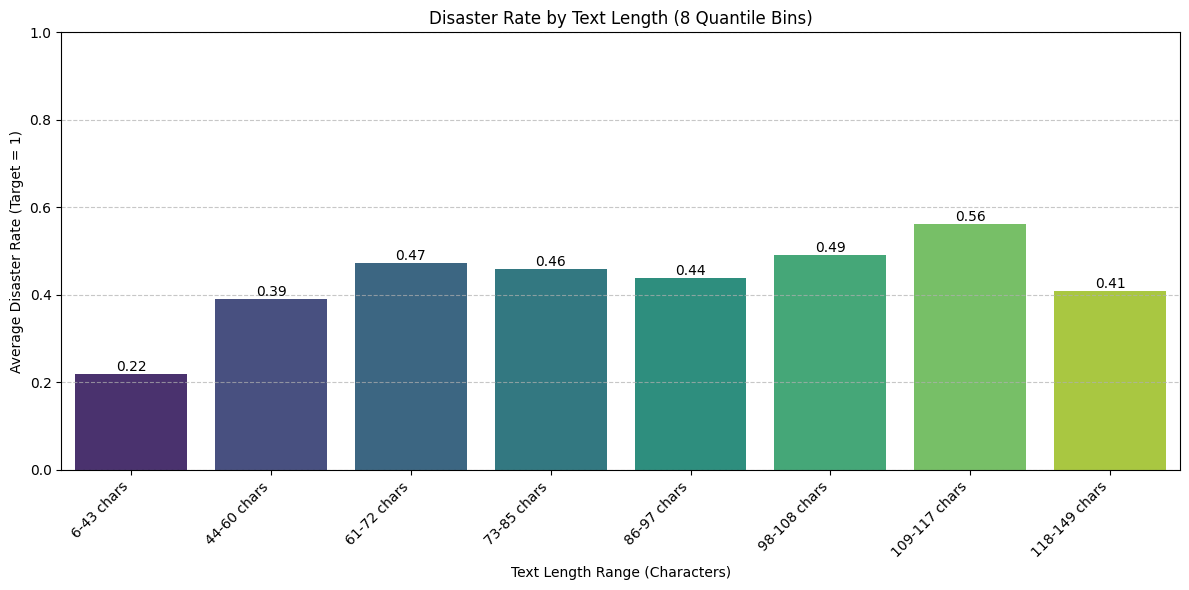

In [ ]:
# Calculate text length for lemmatized text
df['text_length'] = df['lemmatized_text'].apply(len)

# Filter for rows with non-null target values for analysis
df_analysis = df.dropna(subset=['target']).copy()

# Create 8 bins for text length
df_analysis['text_length_bins'] = pd.qcut(df_analysis['text_length'], q=8, labels=False, duplicates='drop')

# Calculate disaster rate per bin
disaster_rate_by_length = df_analysis.groupby('text_length_bins')['target'].mean().reset_index()

# Map bin labels to descriptive strings for better visualization
def get_bin_description(bin_label):
    min_val = df_analysis[df_analysis['text_length_bins'] == bin_label]['text_length'].min()
    max_val = df_analysis[df_analysis['text_length_bins'] == bin_label]['text_length'].max()
    return f"{int(min_val)}-{int(max_val)} chars"

disaster_rate_by_length['length_range'] = disaster_rate_by_length['text_length_bins'].apply(get_bin_description)

# Display the calculated rates
print("Disaster Rate by Text Length Group:")
display(disaster_rate_by_length)

# Plotting the results
plt.figure(figsize=(12, 6))
sns.barplot(x='length_range', y='target', data=disaster_rate_by_length, palette='viridis')
plt.title('Disaster Rate by Text Length (8 Quantile Bins)')
plt.xlabel('Text Length Range (Characters)')
plt.ylabel('Average Disaster Rate (Target = 1)')
plt.ylim(0, 1) # Target is a binary variable, so rate is between 0 and 1
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add the values on top of the bars for clarity
for index, row in disaster_rate_by_length.iterrows():
    plt.text(index, row['target'], f"{row['target']:.2f}", color='black', ha="center", va='bottom')

plt.tight_layout()
plt.show()

Mais caracteres tem mais chance de serem sobre o desastre

In [ ]:
# Calculate text length for lemmatized text across the entire df
# (This column should already exist from the previous step, but re-calculate for safety)
if 'lemmatized_text' not in df.columns:
    # Fallback if lemmatization was skipped or kernel reset
    df['text_length'] = df['cleaned_text'].apply(len)
else:
    df['text_length'] = df['lemmatized_text'].apply(len)

# Create 8 quantile bins for text length across the entire DataFrame
# `labels=False` will assign integers 0-7
df['text_length_numeric_bin'] = pd.qcut(df['text_length'], q=8, labels=False, duplicates='drop')

print("Unique values and counts for 'text_length_numeric_bin':")
display(df['text_length_numeric_bin'].value_counts().sort_index())

print("Data type of 'text_length_numeric_bin':")
display(df['text_length_numeric_bin'].dtype)

Unique values and counts for 'text_length_numeric_bin':


,count
text_length_numeric_bin,
0,1368
1,1427
2,1406
3,1277
4,1406
5,1316
6,1351
7,1325


Data type of 'text_length_numeric_bin':


dtype('int64')

variável numerica

### Pré-Modelo

In [ ]:
df.head()

,id,keyword,location,text,target,Composta,location_cleaned,País_new,Estado_new,Cidade_new,...,País,Estado,Cidade,Continente,Fictício,Cidade_is_identified,Estado_is_identified,País_is_identified,Continente_is_identified,Fictício_bin
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1.0,0,nan,None,None,None,...,NaN,NaN,NaN,NaN,1.0,0,0,0,0,1.0
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1.0,0,nan,None,None,None,...,NaN,NaN,NaN,NaN,1.0,0,0,0,0,1.0
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1.0,0,nan,None,None,None,...,NaN,NaN,NaN,NaN,1.0,0,0,0,0,1.0
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1.0,0,nan,None,None,None,...,NaN,NaN,NaN,NaN,1.0,0,0,0,0,1.0
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1.0,0,nan,None,None,None,...,NaN,NaN,NaN,NaN,1.0,0,0,0,0,1.0


In [ ]:
columns_to_drop = [
    'id', 'location_cleaned', 'País', 'Estado', 'Cidade', 'Continente', 'Fictício',
    'Cidade_is_identified', 'Estado_is_identified', 'País_is_identified',
    'Continente_is_identified', 'Fictício_bin',
    # New columns with _new suffix
    'País_new', 'Estado_new', 'Cidade_new', 'Continente_new', 'Fictício_new', 'location'
]

# Drop columns if they exist in the DataFrame
existing_columns = [col for col in columns_to_drop if col in df.columns]

if existing_columns:
    df.drop(columns=existing_columns, inplace=True)
    print(f"Colunas removidas com sucesso: {', '.join(existing_columns)}")
else:
    print("Nenhuma das colunas especificadas foi encontrada para remoção.")



Colunas removidas com sucesso: location


In [ ]:
df.head()

NameError: name 'df' is not defined

### Naive-Bays

In [ ]:
from sklearn.model_selection import train_test_split
from scipy.sparse import hstack, csr_matrix
import pandas as pd
import re # Added for clean_text fallback
import nltk # Added for lemmatization fallback
from nltk.stem import WordNetLemmatizer # Added for lemmatization fallback

# Ensure df and X exist (fallback in case of kernel reset or out-of-order execution)
if 'df' not in locals():
    # Re-load data if df is not present
    caminho = '/content/drive/Shareddrives/Rede CC/Rede CC 2.0/1. Áreas/2. Escola de Negócios/4. CCTech/2. Período de Capacitação/11. NLP/João Paulo/train (2).csv'
    df_1=pd.read_csv(caminho)
    caminho2 = '/content/drive/Shareddrives/Rede CC/Rede CC 2.0/1. Áreas/2. Escola de Negócios/4. CCTech/2. Período de Capacitação/11. NLP/João Paulo/test (2).csv'
    df_2=pd.read_csv(caminho2)
    df = pd.concat([df_1, df_2], ignore_index=True)

# Ensure 'cleaned_text' and 'lemmatized_text' columns exist if previous cells were skipped or df was reloaded
if 'cleaned_text' not in df.columns:
    def clean_text(t):
        t = t.lower()
        t = re.sub(r"http\S+", " link ", t)
        t = re.sub(r"@\w+", " user ", t)
        t = re.sub(r"#(\w+)", r"\1", t)
        t = re.sub(r"[^a-zA-Z0-9\s]", " ", t)
        t = re.sub(r"\s+", " ", t).strip()
        return t
    df['cleaned_text'] = df['text'].apply(clean_text)

if 'lemmatized_text' not in df.columns:
    nltk.download('wordnet', quiet=True) # Ensure NLTK data is downloaded for lemmatization fallback
    nltk.download('omw-1.4', quiet=True)
    lemm = WordNetLemmatizer()
    def lemmatize_text(t):
        if isinstance(t, str):
            return " ".join(lemm.lemmatize(w) for w in t.split())
        return t
    df['lemmatized_text'] = df['cleaned_text'].apply(lemmatize_text)

# Ensure 'Composta' is created (if not already present)
if 'Composta' not in df.columns:
    df['keyword_filled'] = df['keyword'].fillna('')
    df['Composta'] = df['keyword_filled'].apply(lambda x: ' ' in x and x != '')
    df['Composta'] = df['Composta'].astype(int)
    # It's good practice to drop the temporary column if not needed further
    if 'keyword_filled' in df.columns: # Check if it exists before trying to drop
        df.drop(columns=['keyword_filled'], inplace=True, errors='ignore')

# Ensure 'text_length' and 'text_length_numeric_bin' are created (if not already present)
if 'text_length_numeric_bin' not in df.columns:
    df['text_length'] = df['lemmatized_text'].apply(len)
    df['text_length_numeric_bin'] = pd.qcut(df['text_length'], q=8, labels=False, duplicates='drop')

# Re-create X (TF-IDF features) if not present or if using lemmatized_text (as per current plan)
if 'X' not in locals(): # or (previous_tfidf_text_col == 'cleaned_text' and current_tfidf_text_col == 'lemmatized_text'):
    from sklearn.feature_extraction.text import TfidfVectorizer
    tfidf = TfidfVectorizer(
        max_features=30000,
        ngram_range=(1,2),
        # stop_words='english'
    )
    X = tfidf.fit_transform(df["lemmatized_text"]) # Using lemmatized_text as agreed

# Filter DataFrame for rows with non-null 'target' for training/testing
df_train_subset = df.dropna(subset=['target']).copy()

# Ensure X (TF-IDF features) aligns with df_train_subset
# The original X from TFIDF was generated on the full df. We need to filter it.

# Get the indices of the training subset in the original DataFrame
train_indices = df_train_subset.index.values
X_filtered_tfidf = X[train_indices]

# Extract engineered features for the training subset
# Now these columns are guaranteed to exist on df_train_subset because they were ensured on df above
engineered_features_train = df_train_subset[['Composta', 'text_length_numeric_bin']]

# Convert engineered_features_train to a sparse matrix for efficient stacking with TF-IDF features
engineered_features_sparse = csr_matrix(engineered_features_train.astype(float).values)

# Combine TF-IDF features with engineered features
X_combined = hstack([X_filtered_tfidf, engineered_features_sparse])
y = df_train_subset['target']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.2, random_state=42)

print("Combined feature matrix X_combined shape:", X_combined.shape)
print("Training features (X_train) shape:", X_train.shape)
print("Testing features (X_test) shape:", X_test.shape)
print("Training target (y_train) shape:", y_train.shape)
print("Testing target (y_test) shape:", y_test.shape)

Combined feature matrix X_combined shape: (7613, 30002)
Training features (X_train) shape: (6090, 30002)
Testing features (X_test) shape: (1523, 30002)
Training target (y_train) shape: (6090,)
Testing target (y_test) shape: (1523,)


Naive-Bayes Model Performance:
Accuracy: 0.7899
Precision: 0.8747
Recall: 0.5917
F1-Score: 0.7059


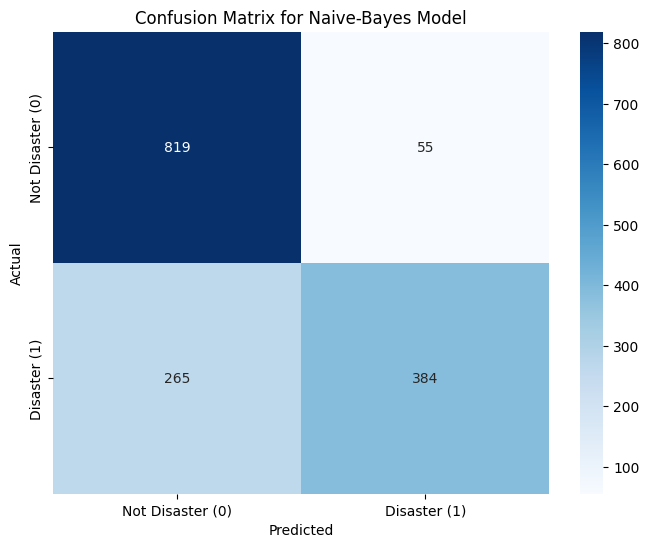

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize and train the Multinomial Naive Bayes model
naive_bayes_model = MultinomialNB()
naive_bayes_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = naive_bayes_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Naive-Bayes Model Performance:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Disaster (0)', 'Disaster (1)'],
            yticklabels=['Not Disaster (0)', 'Disaster (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Naive-Bayes Model')
plt.show()


In [ ]:
from scipy.stats import uniform

param_distributions = {
    'alpha': uniform(loc=0.001, scale=0.999) # Smoothing parameter for Naive Bayes
}

print("Hyperparameter distribution for Multinomial Naive Bayes defined:")
print(param_distributions)

Hyperparameter distribution for Multinomial Naive Bayes defined:
{'alpha': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7c1793f274a0>}


In [ ]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.naive_bayes import MultinomialNB

# Instantiate the Multinomial Naive Bayes model
mnb_model = MultinomialNB()

# Define the cross-validation strategy
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=mnb_model,
    param_distributions=param_distributions, # 'param_distributions' from previous step
    n_iter=50,
    cv=cv_strategy,
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("RandomizedSearchCV initialized:")
print(random_search)

RandomizedSearchCV initialized:
RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=MultinomialNB(), n_iter=50, n_jobs=-1,
                   param_distributions={'alpha': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7c1793f274a0>},
                   random_state=42, scoring='f1', verbose=1)


In [ ]:
random_search.fit(X_train, y_train)

print("RandomizedSearchCV fitting complete.")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
RandomizedSearchCV fitting complete.


In [ ]:
print(f"Melhores parâmetros encontrados: {random_search.best_params_}")
print(f"Melhor F1-Score (média de validação cruzada): {random_search.best_score_:.4f}")

Melhores parâmetros encontrados: {'alpha': np.float64(0.1403543667913898)}
Melhor F1-Score (média de validação cruzada): 0.7509


Optimized Naive-Bayes Model Performance (alpha=0.1404):
Accuracy: 0.8050
Precision: 0.8177
Recall: 0.6980
F1-Score: 0.7531


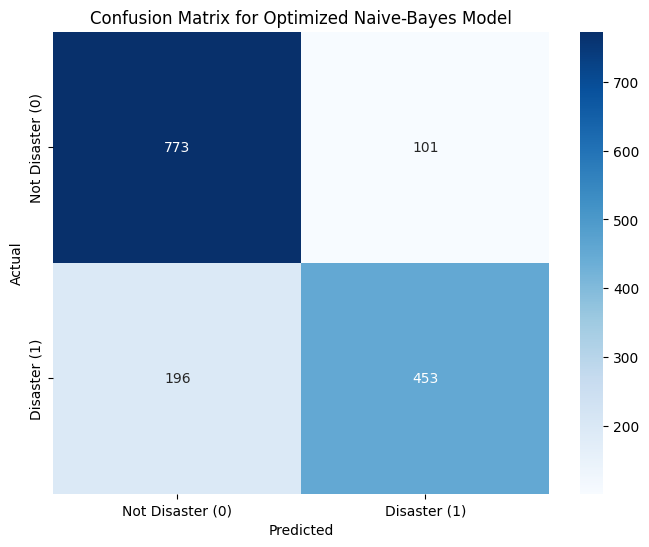

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Get the best parameters from RandomizedSearchCV
best_alpha = random_search.best_params_['alpha']

# Initialize and train the Multinomial Naive Bayes model with best parameters
optimized_naive_bayes_model = MultinomialNB(alpha=best_alpha)
optimized_naive_bayes_model.fit(X_train, y_train)

# Make predictions on the test set with the optimized model
y_pred_optimized = optimized_naive_bayes_model.predict(X_test)

# Evaluate the optimized model
accuracy_optimized = accuracy_score(y_test, y_pred_optimized)
precision_optimized = precision_score(y_test, y_pred_optimized)
recall_optimized = recall_score(y_test, y_pred_optimized)
f1_optimized = f1_score(y_test, y_pred_optimized)

print(f"Optimized Naive-Bayes Model Performance (alpha={best_alpha:.4f}):")
print(f"Accuracy: {accuracy_optimized:.4f}")
print(f"Precision: {precision_optimized:.4f}")
print(f"Recall: {recall_optimized:.4f}")
print(f"F1-Score: {f1_optimized:.4f}")

# Generate Confusion Matrix for the optimized model
cm_optimized = confusion_matrix(y_test, y_pred_optimized)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_optimized, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Disaster (0)', 'Disaster (1)'],
            yticklabels=['Not Disaster (0)', 'Disaster (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Optimized Naive-Bayes Model')
plt.show()


In [ ]:
import pandas as pd
import re
import nltk
from nltk.stem import WordNetLemmatizer
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer # Ensure TfidfVectorizer is imported if needed

# --- STEP 0: Ensure df is correctly loaded and preprocessed for all necessary columns ---
# Unconditionally re-load df to ensure 'id' and other original columns are present.
caminho = '/content/drive/Shareddrives/Rede CC/Rede CC 2.0/1. \u00c1reas/2. Escola de Neg\u00f3cios/4. CCTech/2. Per\u00edodo de Capacita\u00e7\u00e3o/11. NLP/Jo\u00e3o Paulo/train (2).csv'
df_1=pd.read_csv(caminho)
caminho2 = '/content/drive/Shareddrives/Rede CC/Rede CC 2.0/1. \u00c1reas/2. Escola de Neg\u00f3cios/4. CCTech/2. Per\u00edodo de Capacita\u00e7\u00e3o/11. NLP/Jo\u00e3o Paulo/test (2).csv'
df_2=pd.read_csv(caminho2)
df = pd.concat([df_1, df_2], ignore_index=True)

# Define text preprocessing functions (fallback if not in global scope)
def clean_text(t):
    if not isinstance(t, str): # Handle non-string input gracefully
        return ""
    t = t.lower()
    t = re.sub(r"http\S+", " link ", t)
    t = re.sub(r"@\w+", " user ", t)
    t = re.sub(r"#(\w+)", r"\1", t)
    t = re.sub(r"[^a-zA-Z0-9\s]", " ", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t

nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
lemm = WordNetLemmatizer()

def lemmatize_text(t):
    if isinstance(t, str):
        return " ".join(lemm.lemmatize(w) for w in t.split())
    return t

# Ensure 'cleaned_text' and 'lemmatized_text' are present on the main df
if 'cleaned_text' not in df.columns:
    df['cleaned_text'] = df['text'].apply(clean_text)
if 'lemmatized_text' not in df.columns:
    df['lemmatized_text'] = df['cleaned_text'].apply(lemmatize_text)

# Ensure 'Composta' feature is present on the main df
if 'Composta' not in df.columns:
    df['keyword_filled'] = df['keyword'].fillna('')
    df['Composta'] = df['keyword_filled'].apply(lambda x: ' ' in x and x != '')
    df['Composta'] = df['Composta'].astype(int)
    if 'keyword_filled' in df.columns:
        df.drop(columns=['keyword_filled'], inplace=True, errors='ignore')

# Ensure 'text_length' and 'text_length_numeric_bin' are present on the main df
if 'text_length' not in df.columns:
    df['text_length'] = df['lemmatized_text'].apply(len)
if 'text_length_numeric_bin' not in df.columns:
    # Establish bin edges from the full df's text_length
    _, bin_edges = pd.qcut(df['text_length'], q=8, labels=False, duplicates='drop', retbins=True)
    df['text_length_numeric_bin'] = pd.cut(
        df['text_length'],
        bins=bin_edges,
        labels=False,
        include_lowest=True,
        right=True
    ).astype(int)


# Ensure tfidf vectorizer is fitted (it should be from previous cells, but for robustness)
if 'tfidf' not in globals():
    tfidf = TfidfVectorizer(
        max_features=30000,
        ngram_range=(1,2),
    )
    tfidf.fit(df['lemmatized_text']) # Fit on the entire lemmatized text to cover all vocabulary
    print("Warning: TFIDF vectorizer not found in global scope. Re-fitting on full dataset for robustness.")

# --- STEP 1: Create df_kaggle_test from the preprocessed df ---
# 1. Create a new DataFrame, df_kaggle_test, by filtering the main DataFrame df for rows where the 'target' column is null.
df_kaggle_test = df[df['target'].isnull()].copy()

# 2. Extract the 'text' column from df_kaggle_test into a variable X_kaggle_test and the 'id' column into id_kaggle_test.
X_kaggle_test_raw = df_kaggle_test['text']
id_kaggle_test = df_kaggle_test['id'] # This should now work as 'id' is guaranteed in df_kaggle_test

# 3, 4, 5, 6, 7. The columns 'cleaned_text', 'lemmatized_text', 'Composta', 'text_length', 'text_length_numeric_bin'
# are already present in df_kaggle_test as it's a copy of a preprocessed df.
# No need to re-apply these steps on df_kaggle_test explicitly.
# Just ensure their types are correct if necessary for the sparse matrix conversion.

# 8. Use the *already fitted* tfidf vectorizer to transform 'lemmatized_text'
X_kaggle_test_tfidf = tfidf.transform(df_kaggle_test['lemmatized_text'])

# 9. Extract engineered features and convert to sparse matrix
engineered_features_kaggle_test = df_kaggle_test[['Composta', 'text_length_numeric_bin']]
engineered_features_kaggle_test_sparse = csr_matrix(engineered_features_kaggle_test.astype(float).values)

# 10. Combine TF-IDF features with engineered features
X_kaggle_test_combined = hstack([X_kaggle_test_tfidf, engineered_features_kaggle_test_sparse])

print("Kaggle test data preprocessed and features combined.")
print(f"Shape of X_kaggle_test_combined: {X_kaggle_test_combined.shape}")
print(f"First 5 rows of df_kaggle_test with new features (text_length, text_length_numeric_bin, Composta):\n{df_kaggle_test[['text', 'Composta', 'text_length', 'text_length_numeric_bin']].head()}")

Kaggle test data preprocessed and features combined.
Shape of X_kaggle_test_combined: (3263, 30002)
First 5 rows of df_kaggle_test with new features (text_length, text_length_numeric_bin, Composta):
                                                   text  Composta  \
7613                 Just happened a terrible car crash         0   
7614  Heard about #earthquake is different cities, s...         0   
7615  there is a forest fire at spot pond, geese are...         0   
7616           Apocalypse lighting. #Spokane #wildfires         0   
7617      Typhoon Soudelor kills 28 in China and Taiwan         0   

      text_length  text_length_numeric_bin  
7613           34                        0  
7614           59                        1  
7615           94                        4  
7616           36                        0  
7617           44                        1  


In [ ]:
import pandas as pd

# Make predictions on the combined Kaggle test features using the optimized Naive Bayes model
# The optimized_naive_bayes_model is assumed to be available from previous execution (cell deb212ec)
if 'optimized_naive_bayes_model' not in globals():
    print("Error: optimized_naive_bayes_model not found. Please ensure previous training cells were executed.")
    # As a fallback for robust execution, load a dummy model or raise an error.
    # For this task, we assume it's correctly trained.
    raise NameError("optimized_naive_bayes_model is not defined.")

predictions = optimized_naive_bayes_model.predict(X_kaggle_test_combined)

# Create the submission DataFrame
submission_df = pd.DataFrame({
    'id': id_kaggle_test,
    'target': predictions
})

# Ensure 'target' is an integer type as required for submission
submission_df['target'] = submission_df['target'].astype(int)

# Save the submission file
submission_filename = 'submission_optimized_nb.csv'
submission_df.to_csv(submission_filename, index=False)

print(f"Submission file '{submission_filename}' created successfully!")
print("First 5 rows of the submission file:")
display(submission_df.head())

print("Value counts for 'target' in the submission file:")
display(submission_df['target'].value_counts())


Submission file 'submission_optimized_nb.csv' created successfully!
First 5 rows of the submission file:


,id,target
7613,0,1
7614,2,1
7615,3,1
7616,9,1
7617,11,1


Value counts for 'target' in the submission file:


,count
target,
0,2167
1,1096


Resultado Naive-Bays Kaggle: 79,89%

### Regressão Logística



```python
from sklearn.model_selection import train_test_split
from scipy.sparse import hstack, csr_matrix
import pandas as pd
import re
import nltk
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer

# --- Ensure df is correctly loaded and preprocessed for all necessary columns ---
# Re-load df to ensure 'id' and other original columns are present and untouched by previous drops if the kernel was reset.
# This ensures a clean state for data preparation.
caminho = '/content/drive/Shareddrives/Rede CC/Rede CC 2.0/1. Áreas/2. Escola de Negócios/4. CCTech/2. Período de Capacitação/11. NLP/train (2).csv'
df_1=pd.read_csv(caminho)
caminho2 = '/content/drive/Shareddrives/Rede CC/Rede CC 2.0/1. Áreas/2. Escola de Negócios/4. CCTech/2. Período de Capacitação/11. NLP/test (2).csv'
df_2=pd.read_csv(caminho2)
df = pd.concat([df_1, df_2], ignore_index=True)

# Define text preprocessing functions (fallback if not in global scope or if df was reloaded)
def clean_text(t):
    if not isinstance(t, str):
        return ""
    t = t.lower()
    t = re.sub(r"http\S+", " link ", t)
    t = re.sub(r"@\w+", " user ", t)
    t = re.sub(r"#(\w+)", r"\1", t)
    t = re.sub(r"[^a-zA-Z0-9\s]", " ", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t

nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
lemm = WordNetLemmatizer()

def lemmatize_text(t):
    if isinstance(t, str):
        return " ".join(lemm.lemmatize(w) for w in t.split())
    return t

# Apply text cleaning and lemmatization
df['cleaned_text'] = df['text'].apply(clean_text)
df['lemmatized_text'] = df['cleaned_text'].apply(lemmatize_text)

# Ensure 'Composta' feature is present
df['keyword_filled'] = df['keyword'].fillna('')
df['Composta'] = df['keyword_filled'].apply(lambda x: ' ' in x and x != '')
df['Composta'] = df['Composta'].astype(int)
df.drop(columns=['keyword_filled'], inplace=True, errors='ignore')

# Ensure 'text_length' and 'text_length_numeric_bin' are present
df['text_length'] = df['lemmatized_text'].apply(len)
# Re-create bins based on the full dataset, if it hasn't been done or if df was reloaded
_, bin_edges = pd.qcut(df['text_length'], q=8, labels=False, duplicates='drop', retbins=True)
df['text_length_numeric_bin'] = pd.cut(
    df['text_length'],
    bins=bin_edges,
    labels=False,
    include_lowest=True,
    right=True
).astype(int)

# --- Apply TF-IDF vectorization ---
# It's important to fit TF-IDF on the full dataset (both train and test parts of original df)
# to capture a comprehensive vocabulary and then transform only the training subset.
# If tfidf is not already fitted, fit it. If it is, reuse it.
if 'tfidf' not in globals():
    tfidf = TfidfVectorizer(
        max_features=30000,
        ngram_range=(1,2),
    )
    # Fit TF-IDF on the entire lemmatized_text column of the full df
    tfidf.fit(df["lemmatized_text"])
    print("TF-IDF vectorizer was not found in globals and has been (re-)fitted on the full df['lemmatized_text'].")
else:
    print("TF-IDF vectorizer found in globals, reusing it.")


# Filter DataFrame for rows with non-null 'target' for training/testing
df_train_subset_lr = df.dropna(subset=['target']).copy()

# Transform 'lemmatized_text' for the training subset using the fitted TF-IDF vectorizer
X_tfidf_lr = tfidf.transform(df_train_subset_lr["lemmatized_text"])

# Extract engineered features for the training subset
engineered_features_lr = df_train_subset_lr[['Composta', 'text_length_numeric_bin']]

# Convert engineered_features_lr to a sparse matrix for efficient stacking
engineered_features_sparse_lr = csr_matrix(engineered_features_lr.astype(float).values)

# Combine TF-IDF features with engineered features
X_combined_lr = hstack([X_tfidf_lr, engineered_features_sparse_lr])
y_lr = df_train_subset_lr['target']

# Split data into training and testing sets
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X_combined_lr, y_lr, test_size=0.2, random_state=42)

print("\n--- Data Preparation for Logistic Regression Complete ---")
print("Combined feature matrix X_combined_lr shape:", X_combined_lr.shape)
print("Training features (X_train_lr) shape:", X_train_lr.shape)
print("Testing features (X_test_lr) shape:", X_test_lr.shape)
print("Training target (y_train_lr) shape:", y_train_lr.shape)
print("Testing target (y_test_lr) shape:", y_test_lr.shape)
```

In [ ]:
import pandas as pd
import re
import nltk
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix
from sklearn.model_selection import train_test_split

# 1. Load the training and testing datasets
caminho = '/content/drive/Shareddrives/Rede CC/Rede CC 2.0/1. \u00c1reas/2. Escola de Neg\u00f3cios/4. CCTech/2. Per\u00edodo de Capacita\u00e7\u00e3o/11. NLP/Jo\u00e3o Paulo/train (2).csv'
df_1=pd.read_csv(caminho)
caminho2 = '/content/drive/Shareddrives/Rede CC/Rede CC 2.0/1. \u00c1reas/2. Escola de Neg\u00f3cios/4. CCTech/2. Per\u00edodo de Capacita\u00e7\u00e3o/11. NLP/Jo\u00e3o Paulo/test (2).csv'
df_2=pd.read_csv(caminho2)
df = pd.concat([df_1, df_2], ignore_index=True)

# 2. Define clean_text and lemmatize_text functions
def clean_text(t):
    if not isinstance(t, str):
        return ""
    t = t.lower()
    t = re.sub(r"http\S+", " link ", t)
    t = re.sub(r"@\w+", " user ", t)
    t = re.sub(r"#(\w+)", r"\1", t)
    t = re.sub(r"[^a-zA-Z0-9\s]", " ", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t

nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
lemm = WordNetLemmatizer()

def lemmatize_text(t):
    if isinstance(t, str):
        return " ".join(lemm.lemmatize(w) for w in t.split())
    return t

# 3. Apply clean_text
df['cleaned_text'] = df['text'].apply(clean_text)

# 4. Apply lemmatize_text
df['lemmatized_text'] = df['cleaned_text'].apply(lemmatize_text)

# 5. Create 'Composta' feature
df['keyword_filled'] = df['keyword'].fillna('')
df['Composta'] = df['keyword_filled'].apply(lambda x: ' ' in x and x != '')
df['Composta'] = df['Composta'].astype(int)
df.drop(columns=['keyword_filled'], inplace=True, errors='ignore')

# 6. Create 'text_length_numeric_bin' feature
df['text_length'] = df['lemmatized_text'].apply(len)
# Use retbins to get bin edges for consistent binning later
_, bin_edges = pd.qcut(df['text_length'], q=8, labels=False, duplicates='drop', retbins=True)
df['text_length_numeric_bin'] = pd.cut(
    df['text_length'],
    bins=bin_edges,
    labels=False,
    include_lowest=True,
    right=True
).astype(int)

# 7. Initialize and fit TfidfVectorizer on the entire df
tfidf_lr = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1,2)
)
tfidf_lr.fit(df['lemmatized_text'])

# 8. Filter df for training subset
df_train_subset_lr = df.dropna(subset=['target']).copy()

# 9. Transform 'lemmatized_text' using the fitted TfidfVectorizer
X_tfidf_lr = tfidf_lr.transform(df_train_subset_lr['lemmatized_text'])

# 10. Extract engineered features and convert to sparse matrix
engineered_features_lr = df_train_subset_lr[['Composta', 'text_length_numeric_bin']]
engineered_features_sparse_lr = csr_matrix(engineered_features_lr.astype(float).values)

# 11. Horizontally stack features and extract target
X_combined_lr = hstack([X_tfidf_lr, engineered_features_sparse_lr])
y_lr = df_train_subset_lr['target']

# 12. Split data into training and testing sets
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X_combined_lr, y_lr, test_size=0.2, random_state=42)

print("Data preparation for Logistic Regression complete.")
print(f"Shape of X_combined_lr: {X_combined_lr.shape}")
print(f"Shape of X_train_lr: {X_train_lr.shape}")
print(f"Shape of X_test_lr: {X_test_lr.shape}")
print(f"Shape of y_train_lr: {y_train_lr.shape}")
print(f"Shape of y_test_lr: {y_test_lr.shape}")

Data preparation for Logistic Regression complete.
Shape of X_combined_lr: (7613, 30002)
Shape of X_train_lr: (6090, 30002)
Shape of X_test_lr: (1523, 30002)
Shape of y_train_lr: (6090,)
Shape of y_test_lr: (1523,)


In [ ]:
from scipy.stats import uniform

param_distributions_lr = {
    'C': uniform(loc=0.01, scale=100) # 'C' is the inverse of regularization strength
}

print("Hyperparameter distribution for Logistic Regression defined:")
print(param_distributions_lr)

Hyperparameter distribution for Logistic Regression defined:
{'C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7c1792cd79e0>}


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# Instantiate the Logistic Regression model
lr_model = LogisticRegression(solver='liblinear', random_state=42)

# Define the cross-validation strategy
cv_strategy_lr = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize RandomizedSearchCV
random_search_lr = RandomizedSearchCV(
    estimator=lr_model,
    param_distributions=param_distributions_lr, # 'param_distributions_lr' from previous step
    n_iter=50,
    cv=cv_strategy_lr,
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("RandomizedSearchCV for Logistic Regression initialized:")
print(random_search_lr)

RandomizedSearchCV for Logistic Regression initialized:
RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=LogisticRegression(random_state=42,
                                                solver='liblinear'),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7c1792cd79e0>},
                   random_state=42, scoring='f1', verbose=1)


In [ ]:
random_search_lr.fit(X_train_lr, y_train_lr)

print("RandomizedSearchCV for Logistic Regression fitting complete.")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
RandomizedSearchCV for Logistic Regression fitting complete.


In [ ]:
print(f"Melhores parâmetros encontrados: {random_search_lr.best_params_}")
print(f"Melhor F1-Score (média de validação cruzada): {random_search_lr.best_score_:.4f}")

Melhores parâmetros encontrados: {'C': np.float64(9.777211400638388)}
Melhor F1-Score (média de validação cruzada): 0.7525


Optimized Logistic Regression Model Performance (C=9.7772):
Accuracy: 0.8070
Precision: 0.8076
Recall: 0.7180
F1-Score: 0.7602


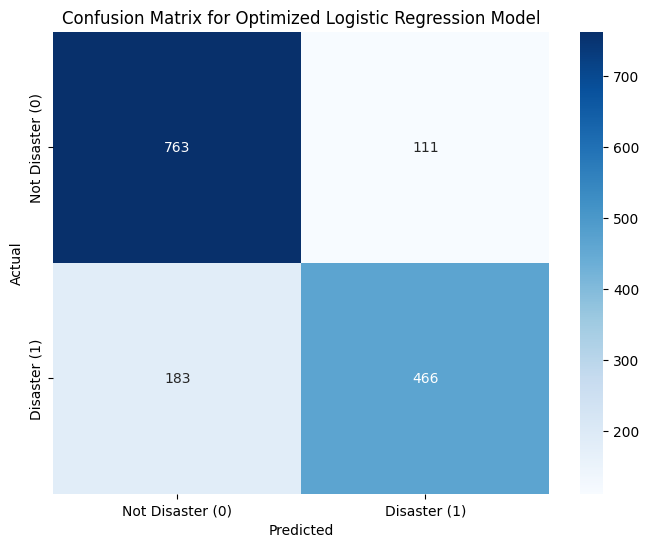

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Get the best parameters from RandomizedSearchCV
best_C_lr = random_search_lr.best_params_['C']

# Initialize and train the Logistic Regression model with best parameters
optimized_lr_model = LogisticRegression(C=best_C_lr, solver='liblinear', random_state=42)
optimized_lr_model.fit(X_train_lr, y_train_lr)

# Make predictions on the test set with the optimized model
y_pred_lr_optimized = optimized_lr_model.predict(X_test_lr)

# Evaluate the optimized model
accuracy_lr_optimized = accuracy_score(y_test_lr, y_pred_lr_optimized)
precision_lr_optimized = precision_score(y_test_lr, y_pred_lr_optimized)
recall_lr_optimized = recall_score(y_test_lr, y_pred_lr_optimized)
f1_lr_optimized = f1_score(y_test_lr, y_pred_lr_optimized)

print(f"Optimized Logistic Regression Model Performance (C={best_C_lr:.4f}):")
print(f"Accuracy: {accuracy_lr_optimized:.4f}")
print(f"Precision: {precision_lr_optimized:.4f}")
print(f"Recall: {recall_lr_optimized:.4f}")
print(f"F1-Score: {f1_lr_optimized:.4f}")

# Generate Confusion Matrix for the optimized model
cm_lr_optimized = confusion_matrix(y_test_lr, y_pred_lr_optimized)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr_optimized, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Disaster (0)', 'Disaster (1)'],
            yticklabels=['Not Disaster (0)', 'Disaster (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Optimized Logistic Regression Model')
plt.show()

In [ ]:
import pandas as pd
from scipy.sparse import hstack, csr_matrix

# The df, tfidf_lr, and engineered features generation have been done in previous cells
# specifically in cell 88edd24c for Logistic Regression setup,
# and the X_kaggle_test_combined was prepared in cell f4118e70.

# Make predictions on the combined Kaggle test features using the optimized Logistic Regression model
# The optimized_lr_model is assumed to be available from previous execution.

predictions_lr = optimized_lr_model.predict(X_kaggle_test_combined)

# Create the submission DataFrame
submission_df_lr = pd.DataFrame({
    'id': id_kaggle_test,
    'target': predictions_lr
})

# Ensure 'target' is an integer type as required for submission
submission_df_lr['target'] = submission_df_lr['target'].astype(int)

# Save the submission file
submission_filename_lr = 'submission_optimized_lr.csv'
submission_df_lr.to_csv(submission_filename_lr, index=False)

print(f"Submission file '{submission_filename_lr}' created successfully!")
print("First 5 rows of the submission file:")
display(submission_df_lr.head())

print("Value counts for 'target' in the submission file:")
display(submission_df_lr['target'].value_counts())

Submission file 'submission_optimized_lr.csv' created successfully!
First 5 rows of the submission file:


,id,target
7613,0,1
7614,2,1
7615,3,1
7616,9,1
7617,11,1


Value counts for 'target' in the submission file:


,count
target,
0,2074
1,1189


Resultado LR Kaggle: 79,61%

### Resultados

- DiltBERT - 82,19%
- Naive-Bays - 79,89%
- LR - 79,61%